# Initalization

In [1]:
%matplotlib inline

In [2]:
import os

import numpy as np
import warnings
warnings.filterwarnings('ignore', message='No contour levels were found')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath

mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
# # mpl.rcParams['pdf.use14corefonts'] = True
# # mpl.rcParams['pdf.fonttype'] = 42
# # mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

colors = ['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

import cmocean

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

import sys
sys.path.append('../analysis/')
# m6toolbox is a python package that has a function that helps visualize vertical sections
import m6toolbox

sys.path.insert(0, '../pittwolfe')
import pittwolfe as pw
from pittwolfe.util import sind, cosd

latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)

## Specify the experiment

In [399]:
####
# flat bottom 2-layer base 0.5º experiment
# expdir = '../../flat/base'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 2-layer 0.25º experiment
# expdir = '../../flat/0.25'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 2-layer 0.5º experiment with GM & K = 500
# expdir = '../../flat/gm_0500'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 3-layer base 0.5º experiment
# expdir = '../../flat/3layer/0.5'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 3-layer 0.25º experiment
expdir = '../../flat/3layer/0.25'
recirc_lon = [0, 8]
recirc_lat = [31, 38]

####
# sloping sidewalls, 0.5º 
# expdir = '../../slope/base'
# recirc_lon0 = 1.25
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]

####
# sloping sidewalls, 0.25º 
# expdir = '../../slope/0.25'
# recirc_lon0 = 4.5
# recirc_lon = [0, 10]
# recirc_lat = [31, 38]


# Function definitions

In [400]:
def savefig(fig, name, pdf=True, png=True):
    if pdf:
        fig.savefig(os.path.join(expdir, name + '.pdf'), bbox_inches='tight')
    if png:
        fig.savefig(os.path.join(expdir, name + '.png'), bbox_inches='tight', dpi=150)

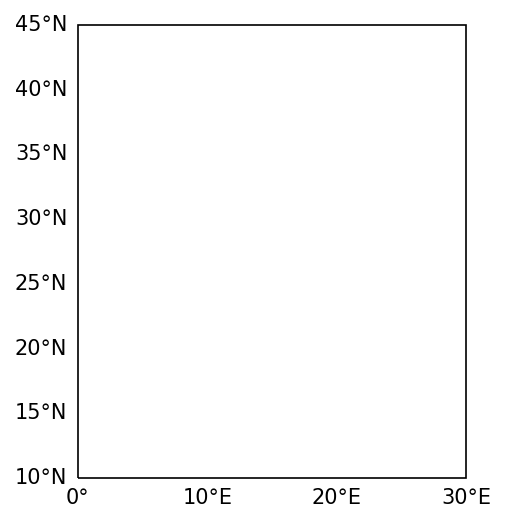

In [401]:
def setup_cartopy_plot(ax=None, bottom_labels=True, left_labels=True):
    data_projection = ccrs.PlateCarree()
    map_projection = ccrs.PlateCarree()
#     map_projection = ccrs.AlbersEqualArea(central_longitude=15, 
#                                           central_latitude=25,
#                                           standard_parallels=(20.0, 50.0))

    if ax is None:
        ax = plt.axes(projection=map_projection)

    ax.set_extent([-0.001, 30.001, 9.999, 45.0001], crs=ccrs.PlateCarree())
    gl = ax.gridlines(xlocs=np.arange(0, 31, 10), draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = bottom_labels
    gl.left_labels = left_labels
    gl.xlines = False
    gl.ylines = False

    vertices = [
        [ 0, 10],
        [30, 10],
        [30, 45],
        [ 0, 45],
        [ 0, 10]
    ]

    path = mpath.Path(vertices).interpolated(20)

#     ax.background_patch.set_facecolor('.5')
#     xlocs = np.arange(-90, 240, 30)
#     ylocs = np.arange(-75, 90, 15)
#     ax.gridlines(xlocs=xlocs, ylocs=ylocs, linewidth=.5)
#     ax.set_boundary(path, transform=data_projection)
    
    return ax

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
setup_cartopy_plot(ax)
savefig(fig, 'test')

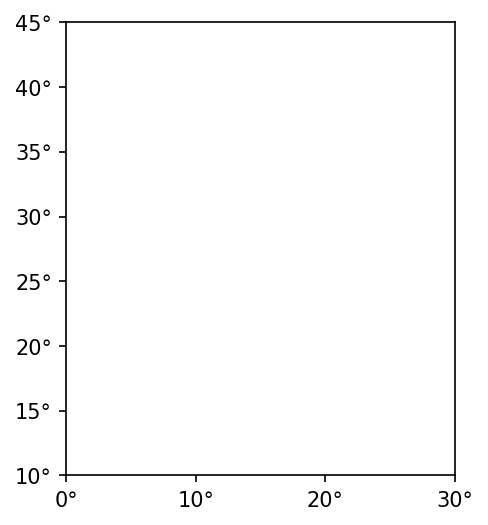

In [402]:
def setup_plan_plot(ax=None):
    if ax is None:
        ax = plt.axes()

    ax.set_xlim(0, 30)
    ax.set_ylim(10, 45)
    
    yticks = np.arange(10, 46, 5)
    latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
    ax.set_yticks(yticks)
    ax.set_yticklabels(latFormatter.format(yticks))
    
    xticks = np.arange(0, 31, 10)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))
    
    ax.set_aspect(1)
    
    return ax

fig, ax = plt.subplots()
setup_plan_plot(ax)
savefig(fig, 'test')

In [403]:
def integer_ticks(vmax, symmetric=True, spacing=None, nticks=None):
    '''
    Returns an array with ticks spaced by an integer and centered around zero.
    
    nticks is the number of non-negative ticks
    '''
    
    if spacing is not None and nticks is not None:
        raise RuntimeError("Can't specify both spacing and nticks")
        
    if spacing is not None:
        if symmetric:
            vmin = -np.floor(vmax/spacing)*spacing
        else:
            vmin = 0
            
        return np.arange(vmin, vmax*(1 + .01), spacing)
    
    if nticks is None:
        nticks = 4
        
    spacing = np.ceil(vmax/nticks)
    if symmetric:
        vmin = -np.floor(vmax/spacing)*spacing
    else:
        vmin = 0
    return np.arange(vmin, vmax*(1 + .01), spacing)
    

In [404]:
def round_up(x, multiple=1):
    '''
    Round up to the next multiple of 'multiple'
    '''
    x = float(x)
    
    if x > 0:
        return np.ceil(x/multiple)*multiple
    elif x < 0:
        return np.floor(x/multiple)*multiple
    else:
        return 0.0
    
def round_down(x, multiple=1):
    '''
    Round down to the next multiple of 'multiple'
    '''
    x = float(x)
    
    if x > 0:
        return np.floor(x/multiple)*multiple
    elif x < 0:
        return np.ceil(x/multiple)*multiple
    else:
        return 0.0

## Vertical modes

We solve the gravity wave problem for the multi-layer shallow water system. The momentum and thickness equations are

$$c u_k = \phi_k, \quad c h_k = H_k u_k, \quad\text{so}\quad c^2 h_k = H_k \phi_k,$$
    
where $k = 1, 2, \ldots K$ for $K$ layers.
    
The pressure anomalies are

$$\phi_k = \sum_{i=0}^{k-1}g'_i \eta_i,  \quad\text{where}\quad g'_0 = g,$$

$\eta_0$ is the SSH. In matrix form, this is

$$
    c \boldsymbol{u} = \boldsymbol{\phi}, \quad \quad c \boldsymbol{h} = \mathbf{{H}} \boldsymbol{u}, \quad
        \boldsymbol{\phi} = \mathbf{{G}}\,\boldsymbol{\eta},
$$

where $\mathbf{{H}}$ is a diagonal matrix with the resting thicknesses on the diagonal and 

$$
    \mathbf{G} = \begin{pmatrix}
        g  &  0     &  0    &  \dots & 0 \\
        g  &  g'_1  &  0    &  \dots & 0 \\
        g  &  g'_1  &  g'_2 &  \dots & 0 \\
        \dots & \dots & \dots & \dots & \dots \\
        g  &  g'_1  &  g'_2 &  \dots & g'_{K-1}
    \end{pmatrix}.
$$

The thickness anomalies satisfy

$$h_k = \eta_{k-1} - \eta_{k} \quad\text{for } k < K, \quad\text{and}\quad h_K = \eta_{K-1},$$

or $\boldsymbol{h} = \mathbf{{B}}^{-1}\, \boldsymbol{\eta}$,

where

$$
    \mathbf{B}^{-1} = \begin{pmatrix}
        1  &  -1  &  0  &  \dots & 0 \\
        0  &   1  &  -1 &  \dots & 0 \\
        0  &   0  &   1 &  \dots & 0 \\
        \dots & \dots & \dots & \dots & \dots \\
        0  &   0  &  0  &  \dots & 1
    \end{pmatrix}.
$$

Putting it together, we have

$$c^2 \boldsymbol{r} = \mathbf{GBH}\boldsymbol{r},$$

where $\boldsymbol{r}$ are the pressure/horizontal velocity modes.

The $\mathbf{B}$ is actually rather simple—it's simply an upper triangular matrix of ones. 

This is a dense, non-self-adjoint generalized eigenvalue problem. The eigenfunctions are not orthogonal, but satisfy a biorthogonality relationship with the adjoint eigenfunctions, $\boldsymbol{r}^\dagger$. For small problems, the adjoint is easily calculated from the inverse:

$$\mathbf{R}^\dagger = \mathbf{R}^{-\mathrm{T}}$$

The interface modes can be found by solving the problem 

$$c^2 \boldsymbol{s} = \mathbf{BHG}\boldsymbol{s}$$

In [405]:
def pressure_modes(gprime, h):
    '''
    Calculate the pressure/horizontal velocity vertical modes for a K-layer fluid.
    
    Parameters
    ----------
        gprime : (K,) array
                 Reduced gravities with the first entry the full gravity.
        h :      ( ..., K) array
                 Layer thicknesses.
    
    Returns
    -------
        c : (K, ) array
            The wave speeds ordered in decreasing magntitude.
        R : ( ..., K, K) array
            The vertical modes.
        Rdag : (..., K, K) array
            Adjoint vertical modes
            
    Notes
    -----
    The vertical modes are normalzied so that R[:,k].T@R[:,k] = 1. Howewver, except under very 
    special conditions, the vertical modes are not orthogonal, but satisfy the biorthogonality 
    relationship with the adjoint modes Rdag.T@R = I.
        
    '''
    h = np.atleast_2d(h)
    
    Nl = len(gprime)
    dims = h.shape[:-1]
    
    # I feel like there should be a way to do this all at once, but I can't figure it out
    H = np.zeros(dims + (Nl, Nl))
    G = np.zeros((Nl, Nl))

    for zl in range(Nl):
        H[...,zl,zl] = h[...,zl]
        G[zl:,zl] = gprime[zl]

    # This is a discrete integration matrix
    B = np.tri(Nl).T

    # The stretching(-ish) matrix
    Γ = G@B@H
    λ, R = np.linalg.eig(Γ)

    c = np.sqrt(λ)
    idx = np.argsort(c, axis=-1)[...,::-1]
    c = np.take_along_axis(c, idx, axis=-1)
    R = np.take_along_axis(R, np.expand_dims(idx, axis=-2), axis=-1)

    # Pick the sign so that the upper layer is positive
    R = R*np.expand_dims(np.sign(R[...,0,:]), axis=-2)

    # The adjoint modes
    Rdag = np.linalg.inv(R).swapaxes(-1, -2)
    
    return c, R, Rdag



def interface_modes(gprime, h):
    '''
    Calculate the interface vertical modes for a K-layer fluid.
    
    Parameters
    ----------
        gprime : (K,) array
                 Reduced gravities with the first entry the full gravity.
        h :      ( ..., K) array
                 Layer thicknesses.
    
    Returns
    -------
        c : (K, ) array
            The wave speeds ordered in decreasing magntitude.
        S : ( ..., K, K) array
            The vertical modes.
        Sdag : (..., K, K) array
            Adjoint vertical modes
            
    Notes
    -----
    The vertical modes are normalzied so that S[:,k].T@S[:,k] = 1. Howewver, except under very 
    special conditions, the vertical modes are not orthogonal, but satisfy the biorthogonality 
    relationship with the adjoint modes Sdag.T@S = I.
        
    '''
    h = np.atleast_2d(h)
    
    Nl = len(gprime)
    dims = h.shape[:-1]
    
    # I feel like there should be a way to do this all at once, but I can't figure it out
    H = np.zeros(dims + (Nl, Nl))
    G = np.zeros((Nl, Nl))

    for zl in range(Nl):
        H[...,zl,zl] = h[...,zl]
        G[zl:,zl] = gprime[zl]

    # This is a discrete integration matrix
    B = np.tri(Nl).T

    # The stretching(-ish) matrix
    Γ = B@Hmat@G
    λ, S = np.linalg.eig(Γ)

    c = np.sqrt(λ)
    idx = np.argsort(c, axis=-1)[...,::-1]
    c = np.take_along_axis(c, idx, axis=-1)
    S = np.take_along_axis(S, np.expand_dims(idx, axis=-2), axis=-1)

    # Pick the sign so that the upper layer is positive
    S = S*np.expand_dims(np.sign(S[...,0,:]), axis=-2)

    # The adjoint modes
    Sdag = np.linalg.inv(S).swapaxes(-1, -2)
    
    return c, S, Sdag

# Load datasets

## Constants

In [406]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3
Ah = 1e4
Δλ = 0.5 # zonal grid spacing

NTavg = 10 # number of averaging times to average
tavg = slice(-NTavg, None)

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [407]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [408]:
grid = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean_geometry.nc')).rename(coord_map_h)
ic = xr.open_dataset(os.path.join(expdir, 'OUTPUT/MOM_IC.nc')).squeeze().rename({**coord_map_h, **coord_map_v})

max_depth = float(grid.D.max())

grid['zi'] = ic.zi
grid['zl'] = ic.zl

Nx = len(grid.xh)
Ny = len(grid.yh)
Nl = len(grid.zl)

grid['gprime'] = (('zl',), g*np.hstack(([1], (grid.zl.diff(dim='zl')/ρ0).values)))

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid['maskH'] = grid.wet
grid['maskU'] = (['yh', 'xq'], np.ones((Ny, Nx+1)))
grid['maskU'][:,[0, -1]] = 0
grid['maskV'] = (['yq', 'xh'], np.ones((Ny+1, Nx)))
grid['maskV'][[0, -1],:] = 0

grid['maskZ'] = (['yq', 'xq'], np.ones((Ny+1, Nx+1)))
grid['maskZ'][[0, -1],:] = 0
grid['maskZ'][:,[0, -1]] = 0

# width of the basin in meters
grid['Lx_q'] = a*np.deg2rad(grid.geolonb.isel(xq=-1,yq=0))*cosd(grid.yq)
grid['Lx_h'] = a*np.deg2rad(grid.geolonb.isel(xq=-1,yq=0))*cosd(grid.yh)

grid

<xarray.Dataset>
Dimensions:  (yh: 161, xh: 120, yq: 162, xq: 121, zi: 4, zl: 3)
Coordinates:
  * yh       (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * xh       (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * yq       (yq) float64 10.0 10.25 10.49 10.74 ... 44.33 44.5 44.68 44.86
  * xq       (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 29.0 29.25 29.5 29.75 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03 1.039e+03
  * zl       (zl) float64 1.035e+03 1.037e+03 1.038e+03
Data variables: (12/30)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 4e+03 4e+03 4e+03 4e+03 ... 4e+03 4e+03 4e+03
    f        (yq, xq) float64 ...
    ...       ...
    maskH    (yh, xh) float64 ...
    maskU    (yh, xq) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    maskV    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    maskZ    (yq, xq) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Lx_q     (yq) float64 3.285e+06 3.282e+06 3.28e+06 ... 2.371e+06 2.364e+06
    Lx_h     (yh) float64 3.283e+06 3.281e+06 3.278e+06 ... 2.375e+06 2.368e+06
Attributes:
    filename:  ./ocean_geometry.nc

In [409]:
grid_op = xgcm.Grid(grid, periodic=False, boundary='fill', fill_value=0, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, boundary='fill'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, boundary='fill'):
  * inner    zl
  * outer    zi

## Forcing

In [410]:
forcing = xr.open_dataset(os.path.join(expdir, 'INPUT/forcing.nc'))

# make sure the coordinates match exactly
forcing['xh'] = grid.xh 
forcing['xq'] = grid.xq[:-1]
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]

forcing['uEk'] =  forcing.STRESS_Y/grid.fq/ρ0
forcing['vEk'] = -forcing.STRESS_X/grid.fh/ρ0
forcing['wEk'] = grid.maskZ*(grid_op.diff(forcing.uEk*grid.dyCv, 'X') + grid_op.diff(forcing.vEk*grid.dxCu, 'Y'))/grid.Aq
forcing['wsc'] = grid.maskZ*(grid_op.diff(forcing.STRESS_Y*grid.dyCv, 'X') - grid_op.diff(forcing.STRESS_X*grid.dxCu, 'Y'))/grid.Aq/ρ0

forcing

<xarray.Dataset>
Dimensions:   (yh: 161, xh: 120, yq: 161, xq: 120)
Coordinates:
  * yh        (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * xh        (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * yq        (yq) float64 10.0 10.25 10.49 10.74 ... 44.15 44.33 44.5 44.68
  * xq        (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 28.75 29.0 29.25 29.5 29.75
    Time      timedelta64[ns] 00:00:00
Data variables:
    STRESS_X  (yh, xq) float64 -0.1208 -0.1208 -0.1208 ... 0.002818 0.002818
    STRESS_Y  (yq, xh) float64 ...
    uEk       (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    vEk       (yh, xq) float64 4.556 4.556 4.556 ... -0.02651 -0.02651 -0.02651
    wEk       (yq, xq) float64 0.0 0.0 0.0 0.0 ... 1.053e-06 1.053e-06 1.053e-06
    wsc       (yq, xq) float64 0.0 0.0 0.0 0.0 ... 1.074e-10 1.074e-10 1.074e-10

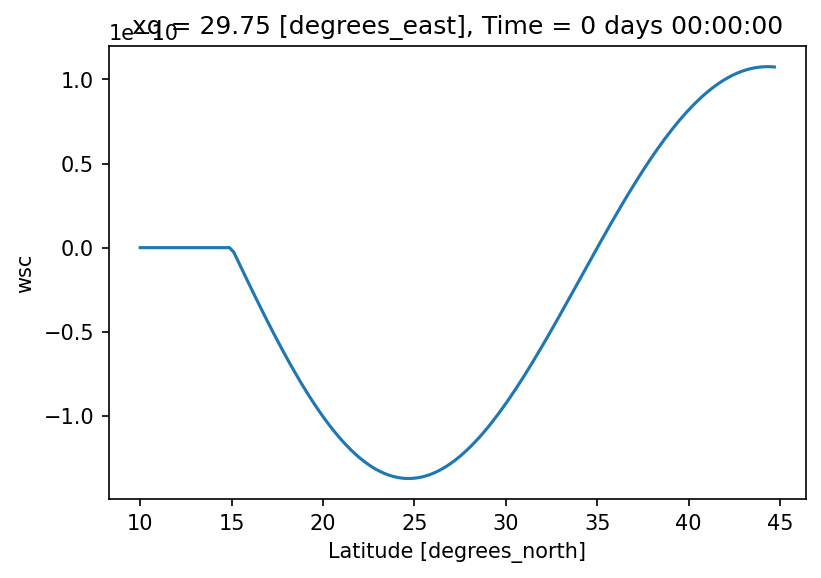

In [411]:
forcing.wsc.isel(xq=-1).plot()

## Statistics

In [412]:
stats = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean.stats.nc'))
stats

<xarray.Dataset>
Dimensions:        (Layer: 3, Interface: 4, Time: 84513)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.037e+03 1.038e+03
  * Interface      (Interface) float64 1.034e+03 1.036e+03 1.037e+03 1.039e+03
  * Time           (Time) timedelta64[ns] 0 days 1 days ... 84512 days
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [413]:
prog = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/ave_prog*.nc'), decode_times=False)
prog

<xarray.Dataset>
Dimensions:     (xq: 121, yh: 161, zl: 3, time: 230, nv: 2, xh: 120, yq: 162, zi: 4)
Coordinates:
  * xq          (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 29.25 29.5 29.75 30.0
  * yh          (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * zl          (zl) float64 1.035e+03 1.037e+03 1.038e+03
  * time        (time) float64 180.0 540.0 900.0 ... 8.226e+04 8.262e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * yq          (yq) float64 10.0 10.25 10.49 10.74 ... 44.33 44.5 44.68 44.86
  * zi          (zi) float64 1.034e+03 1.036e+03 1.037e+03 1.039e+03
Data variables:
    u           (time, zl, yh, xq) float32 dask.array<chunksize=(10, 3, 161, 121), meta=np.ndarray>
    v           (time, zl, yq, xh) float32 dask.array<chunksize=(10, 3, 162, 120), meta=np.ndarray>
    h           (time, zl, yh, xh) float32 dask.array<chunksize=(10, 3, 161, 120), meta=np.ndarray>
    e           (time, zi, yh, xh) float32 dask.array<chunksize=(10, 4, 161, 120), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(10, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

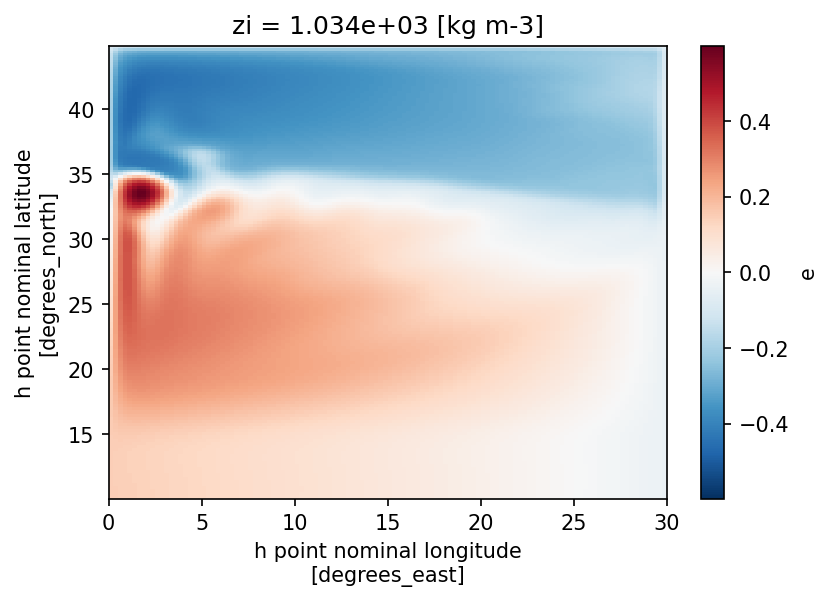

In [414]:
pc = (prog.e.isel(time=tavg, zi=0)).mean(dim='time').plot()

## Snapshots

In [415]:
snapshot = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/prog_*.nc'), decode_times=False)
snapshot

<xarray.Dataset>
Dimensions:  (xq: 121, yh: 161, zl: 3, time: 230, xh: 120, yq: 162, zi: 4)
Coordinates:
  * xq       (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 29.0 29.25 29.5 29.75 30.0
  * yh       (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * zl       (zl) float64 1.035e+03 1.037e+03 1.038e+03
  * time     (time) float64 360.0 720.0 1.08e+03 ... 8.244e+04 8.28e+04
  * xh       (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * yq       (yq) float64 10.0 10.25 10.49 10.74 ... 44.33 44.5 44.68 44.86
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03 1.039e+03
Data variables:
    u        (time, zl, yh, xq) float32 dask.array<chunksize=(10, 3, 161, 121), meta=np.ndarray>
    v        (time, zl, yq, xh) float32 dask.array<chunksize=(10, 3, 162, 120), meta=np.ndarray>
    h        (time, zl, yh, xh) float32 dask.array<chunksize=(10, 3, 161, 120), meta=np.ndarray>
    e        (time, zi, yh, xh) float32 dask.array<chunksize=(10, 4, 161, 120), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

## Continuity

In [416]:
cont = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/cont*.nc'), decode_times=False)
cont

<xarray.Dataset>
Dimensions:     (xq: 121, yh: 161, zl: 3, time: 230, nv: 2, xh: 120, yq: 162)
Coordinates:
  * xq          (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 29.25 29.5 29.75 30.0
  * yh          (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * zl          (zl) float64 1.035e+03 1.037e+03 1.038e+03
  * time        (time) float64 180.0 540.0 900.0 ... 8.226e+04 8.262e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * yq          (yq) float64 10.0 10.25 10.49 10.74 ... 44.33 44.5 44.68 44.86
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(10, 3, 161, 121), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(10, 3, 162, 120), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(10, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

# Calculations

## Deformation radii

In [417]:
celerity, R, Rdag = pressure_modes(grid.gprime, prog.h.isel(time=tavg).mean(dim='time').transpose('yh', 'xh', 'zl'))

deformation_radii = celerity[...,1:]/np.expand_dims(grid.fh.values, axis=(1, 2))

## Instantenous vorticity

In [418]:
snapshot['zeta'] = (grid_op.diff(snapshot.v*grid.dyCv, 'X') - grid_op.diff(snapshot.u*grid.dxCu, 'Y'))/grid.Aq

## Streamfunctions

In [419]:
psi = grid_op.cumsum(cont.vh.isel(time=tavg).mean(dim='time'), axis='X', to='outer', boundary='fill')/1e6
psiB = psi.sum(dim='zl')

In [420]:
# argmax has a hard time with dask
fld = psi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5)).load()
idx = fld.argmax(dim=['xq', 'yq'])

recirc_lon0 = float(fld.isel(idx).xq.isel(zl=0))
recirc_latS = float(fld.isel(idx).yq.isel(zl=0))

idx = fld.argmin(dim=['xq', 'yq'])
recirc_latN = float(fld.isel(idx).yq.isel(zl=1))

## TWA quantities

### Thicknesses and velocities

In [421]:
h_at_u = grid_op.interp(prog.h.isel(time=tavg).mean(dim='time'), 'X').where(grid.maskU > 0)
h_at_v = grid_op.interp(prog.h.isel(time=tavg).mean(dim='time'), 'Y').where(grid.maskV > 0)
h_at_q = grid_op.interp(h_at_u.fillna(0), 'Y').where(grid.maskZ > 0)


# TWA velocities
uhat = cont.uh.isel(time=tavg).mean(dim='time')/h_at_u/grid.dyCuo
vhat = cont.vh.isel(time=tavg).mean(dim='time')/h_at_v/grid.dxCvo

In [422]:
twa = xr.Dataset({'h': prog.h.isel(time=tavg).mean(dim='time'), 'h_at_u': h_at_u, 'h_at_v': h_at_v, 'h_at_q': h_at_q,
                  'uhat': uhat, 'vhat': vhat})
twa

<xarray.Dataset>
Dimensions:  (yh: 161, zl: 3, xh: 120, xq: 121, yq: 162)
Coordinates:
  * yh       (yh) float64 10.12 10.37 10.61 10.86 ... 44.24 44.42 44.59 44.77
  * zl       (zl) float64 1.035e+03 1.037e+03 1.038e+03
  * xh       (xh) float64 0.125 0.375 0.625 0.875 ... 29.12 29.37 29.62 29.87
  * xq       (xq) float64 0.0 0.25 0.5 0.75 1.0 ... 29.0 29.25 29.5 29.75 30.0
    Time     timedelta64[ns] 00:00:00
  * yq       (yq) float64 10.0 10.25 10.49 10.74 ... 44.33 44.5 44.68 44.86
Data variables:
    h        (zl, yh, xh) float32 dask.array<chunksize=(3, 161, 120), meta=np.ndarray>
    h_at_u   (zl, yh, xq) float32 dask.array<chunksize=(3, 161, 1), meta=np.ndarray>
    h_at_v   (zl, yq, xh) float32 dask.array<chunksize=(3, 1, 120), meta=np.ndarray>
    h_at_q   (zl, yq, xq) float32 dask.array<chunksize=(3, 1, 1), meta=np.ndarray>
    uhat     (zl, yh, xq) float64 dask.array<chunksize=(3, 161, 1), meta=np.ndarray>
    vhat     (zl, yq, xh) float64 dask.array<chunksize=(3, 1, 120), meta=np.ndarray>

### Vorticity

The "vorticity" field appearing in the TWA is 

$$
\zeta^\sharp = \frac{1}{\Delta x \Delta y}\left[\delta_i(\Delta y \hat{v})  - \delta_j(\Delta x\hat{u})\right],
$$

where the hats are designate thickness-weighted quantities. This is not the TWA of the vorticity, hence the sharp sign.

The PV is

$$
\Pi^\sharp = \frac{\zeta^\sharp + f}{\bar{h}}.
$$

In [423]:
twa['zeta'] = (grid_op.diff(twa.vhat*grid.dyCv, 'X') - grid_op.diff(twa.uhat*grid.dxCu, 'Y'))/grid.Aq
twa['Pi'] = ((twa.zeta + grid.fq)/twa.h_at_q).where(twa.h_at_q > 1)

# Plot

## Convergence

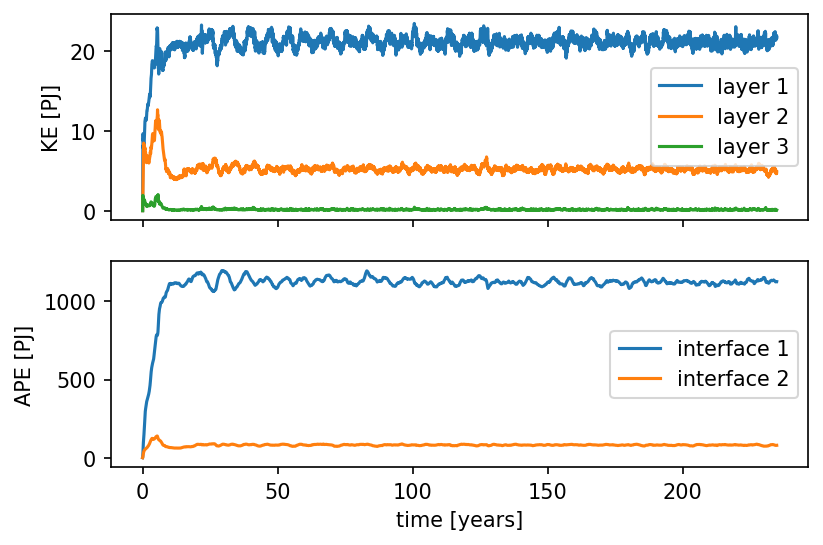

In [424]:
years = np.arange(len(stats.Time))/360

fig, axs = plt.subplots(nrows=2, sharex=True)

ax = axs[0]
for zl in range(Nl):
    ax.plot(years, stats.KE.isel(Layer=zl)/1e15, label='layer ' + str(zl+1))
ax.legend()
ax.set_ylabel('KE [PJ]')

ax = axs[1]
for zi in range(1,Nl):
    ax.plot(years, stats.APE.isel(Interface=zi)/1e15, label='interface ' + str(zi))
ax.legend()
ax.set_ylabel('APE [PJ]')
ax.set_xlabel('time [years]')

savefig(fig, 'energy')

## Interfaces

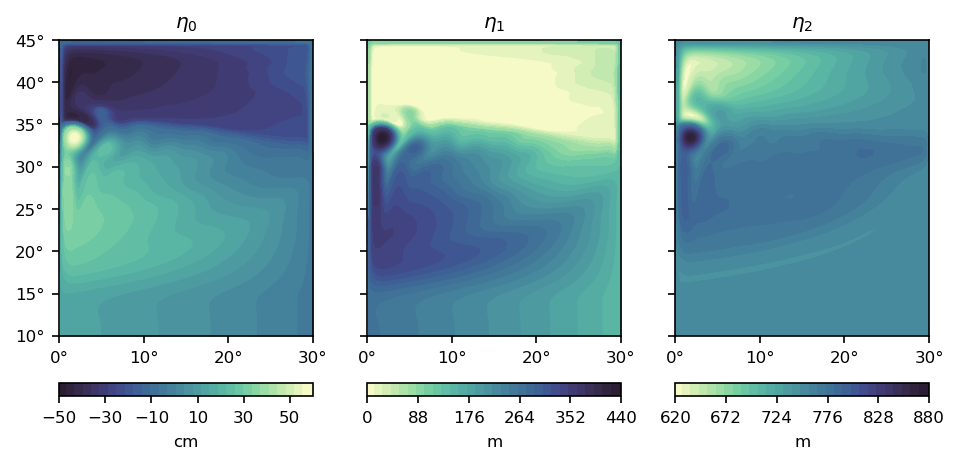

In [425]:
with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))


    ax = axs[0]
    setup_plan_plot(ax)
    fld = 100*prog.e.isel(zi=0).isel(time=tavg).mean(dim='time')
    vmax =  round_up(fld.max(), 10)
    vmin =  round_up(fld.min(), 10)
    levels = np.linspace(vmin, vmax, 31)
    cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep_r')
    # This is the fix for the white lines between contour levels
    for c in cs.collections:
        c.set_edgecolor('face')
    ax.set_aspect(1)
    ax.set_title('$\eta_0$')
    cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, ticks=np.arange(vmin, vmax+1, 20), label='cm')
    cbar.solids.set_edgecolor('face')
    
    for zi in range(1, Nl):
        ax = axs[zi]
        setup_plan_plot(ax)
        fld = -prog.e.isel(zi=zi).isel(time=tavg).mean(dim='time')
        # vmax = float(fld.max())
        # vmin = float(fld.min())
        vmax = round_up(fld.max(), 10)
        vmin = round_down(fld.min(), 10)
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title('$\eta_' + str(zi) + '$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='m', 
                     ticks=integer_ticks(vmax-vmin, nticks=5, symmetric=False)+vmin).solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'interface_depth')

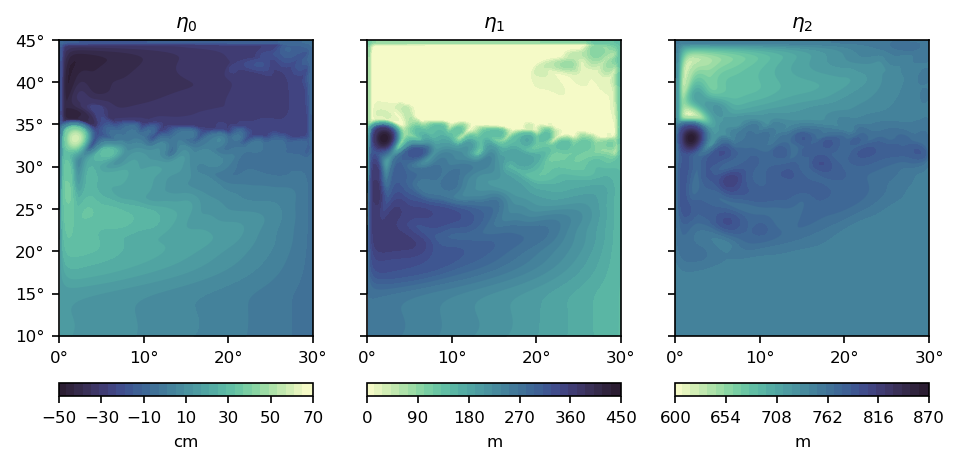

In [426]:
time = -1

with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))


    ax = axs[0]
    setup_plan_plot(ax)
    fld = 100*snapshot.e.isel(zi=0,time=time)
    vmax =  round_up(fld.max(), 10)
    vmin =  round_up(fld.min(), 10)
    levels = np.linspace(vmin, vmax, 31)
    cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep_r')
    # This is the fix for the white lines between contour levels
    for c in cs.collections:
        c.set_edgecolor('face')
    ax.set_aspect(1)
    ax.set_title('$\eta_0$')
    cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, ticks=np.arange(vmin, vmax+1, 20), label='cm')
    cbar.solids.set_edgecolor('face')
    
    for zi in range(1, Nl):
        ax = axs[zi]
        setup_plan_plot(ax)
        fld = -snapshot.e.isel(zi=zi,time=time)
        # vmax = float(fld.max())
        # vmin = float(fld.min())
        vmax = round_up(fld.max(), 10)
        vmin = round_down(fld.min(), 10)
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title('$\eta_' + str(zi) + '$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='m', 
                     ticks=integer_ticks(vmax-vmin, nticks=5, symmetric=False)+vmin).solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'snapshot_interface_depth')

## Deformation radii

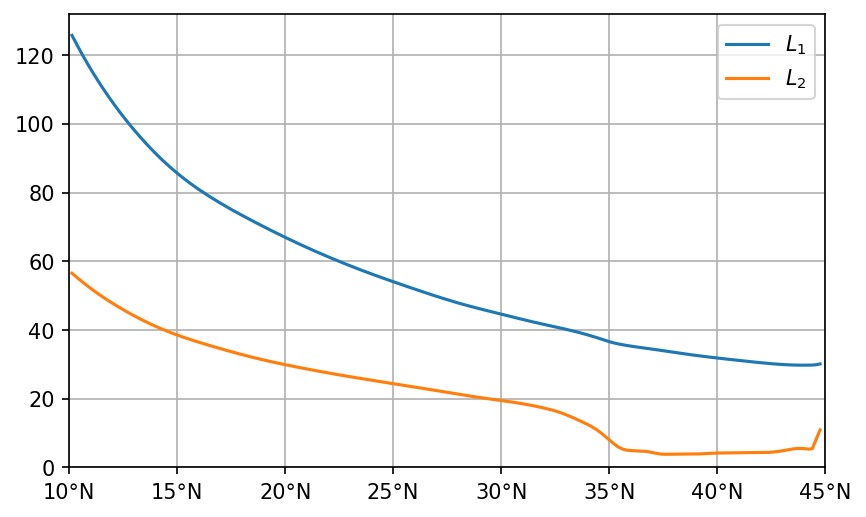

In [427]:
fig, ax = plt.subplots(ncols=1, figsize=(6.5, 4))

for zl in range(Nl-1):
    fld = np.mean(deformation_radii[:,:,zl]/1e3, axis=1)
    # fld = deformation_radii[:,4,zl]/1e3
    ax.plot(grid.yh, fld, label='$L_' + str(zl+1) + '$')
    
ax.legend()
ax.set_xlim(10, 45)
ax.set_ylim(0, ax.get_ylim()[-1])
ax.grid()

xticks = np.arange(10, 50, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=True)
ax.set_xticks(xticks, labels=latFormatter.format(xticks));

savefig(fig, 'deformation_radii')

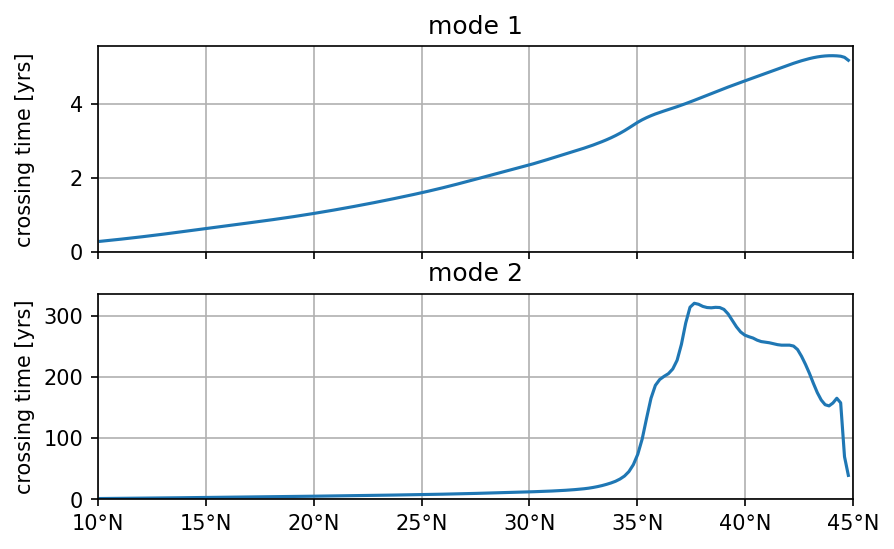

In [428]:
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(6.5, 4))

for zl, ax in enumerate(axs):
    fld = grid.Lx_h/(grid.βh*np.mean(deformation_radii[:,:,zl], axis=1)**2)/3600/24/360
    # fld = deformation_radii[:,4,zl]/1e3
    ax.plot(grid.yh, fld)
    ax.set_title('mode ' + str(zl+1))
    ax.set_ylim(0, ax.get_ylim()[-1])
    ax.grid()
    ax.set_ylabel('crossing time [yrs]')

ax.set_xlim(10, 45)

xticks = np.arange(10, 50, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=True)
ax.set_xticks(xticks, labels=latFormatter.format(xticks));

fig.align_ylabels(axs)
savefig(fig, 'rossby_crossing_time')

## WBCs

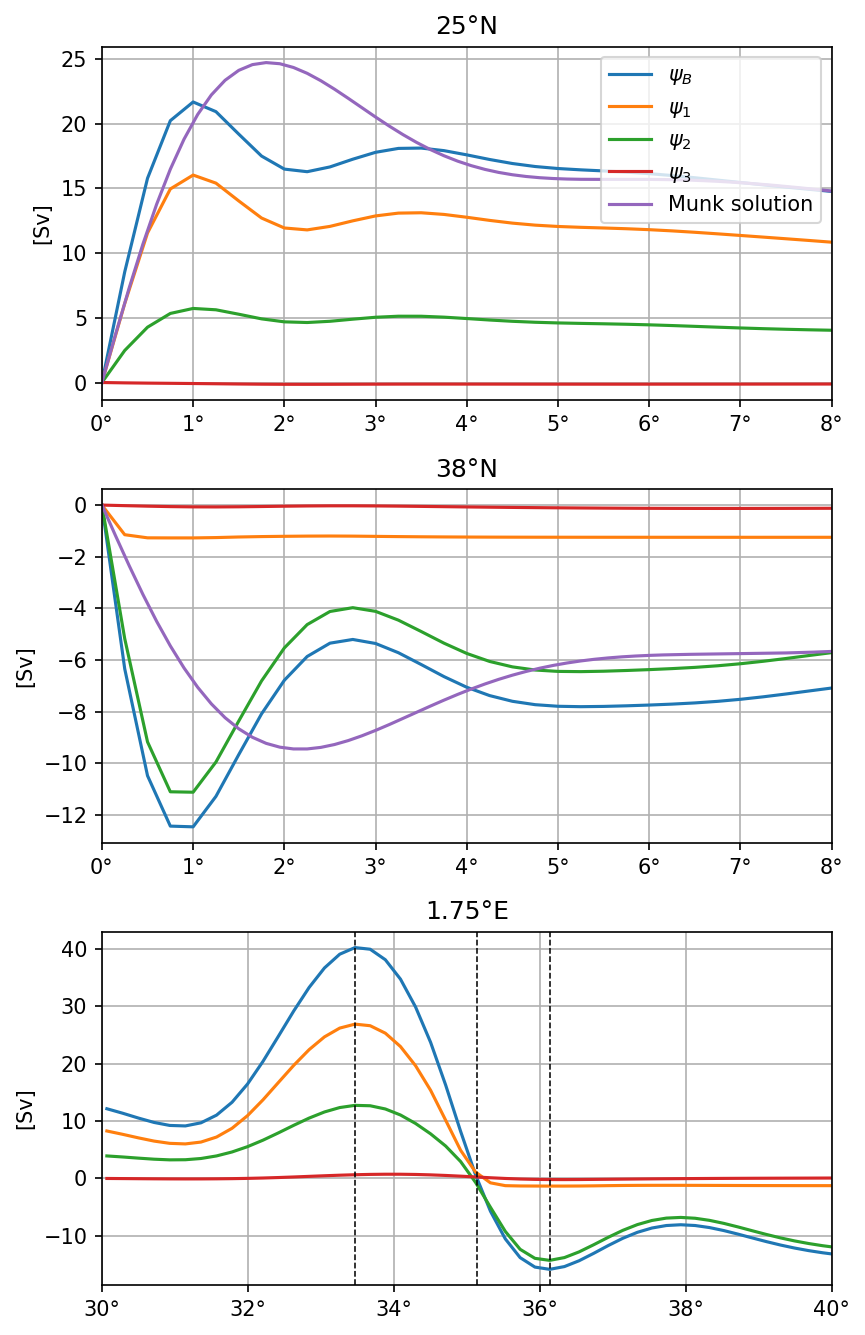

In [429]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

psiI = -(forcing.wsc.isel(xq=-1)*grid.Lx_q/grid.βq)/1e6 # interior streamfunction from Sverdrup theory
xx = np.linspace(0, 1, 201)

for n, lat in enumerate([25, 38]):
    ax = axs[n]

    # Munk width
    δm = (Ah/grid.βq.sel(yq=lat, method='nearest').values)**(1/3)/(a*np.deg2rad(30)*cosd(lat))

    fld = psiB.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    ax.plot(fld.xq, fld, label='$\psi_B$')
    fld = psi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    for zl in range(Nl):
        ax.plot(fld.xq, fld.isel(zl=zl), label='$\psi_' + str(zl+1) + '$')
    ax.plot(30*xx, float(psiI.sel(yq=lat, method='nearest')) 
            * (1 - xx - np.exp(-xx/(2*δm))*(np.cos(np.sqrt(3)*xx/(2*δm)) - 1/np.sqrt(3)*np.sin(np.sqrt(3)*xx/(2*δm)))),
           label='Munk solution')
    ax.grid()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')

axs[0].legend(loc='upper right')

for ax in axs[:-1]:
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))

ax = axs[2]
lon = recirc_lon0
fld = psiB.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld, label='$\psi_B$')
fld = psi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
for zl in range(Nl):
    ax.plot(fld.yq, fld.isel(zl=zl), label='$\psi_' + str(zl+1) + '$')
ax.grid()
ax.set_xlim([30, 40])
# ax.legend()
ax.set_title('{:.2f}\N{DEGREE SIGN}E'.format(recirc_lon0))
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


# find the latitude of the zero-crossing of psiB
fld = psiB.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
idx = int(np.nonzero(fld[:-1].values*fld[1:].values <= 0)[0])
recirc_lat0 = float((fld.isel(yq=idx+1)*fld.yq.isel(yq=idx) - fld.isel(yq=idx)*fld.yq.isel(yq=idx+1))
                    / (fld.isel(yq=idx+1) - fld.isel(yq=idx)))
ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
ax.axvline(recirc_latS, color='k', ls='--', lw=.75)

for ax in axs:
    ax.set_ylabel('[Sv]')

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_streamfunctions')

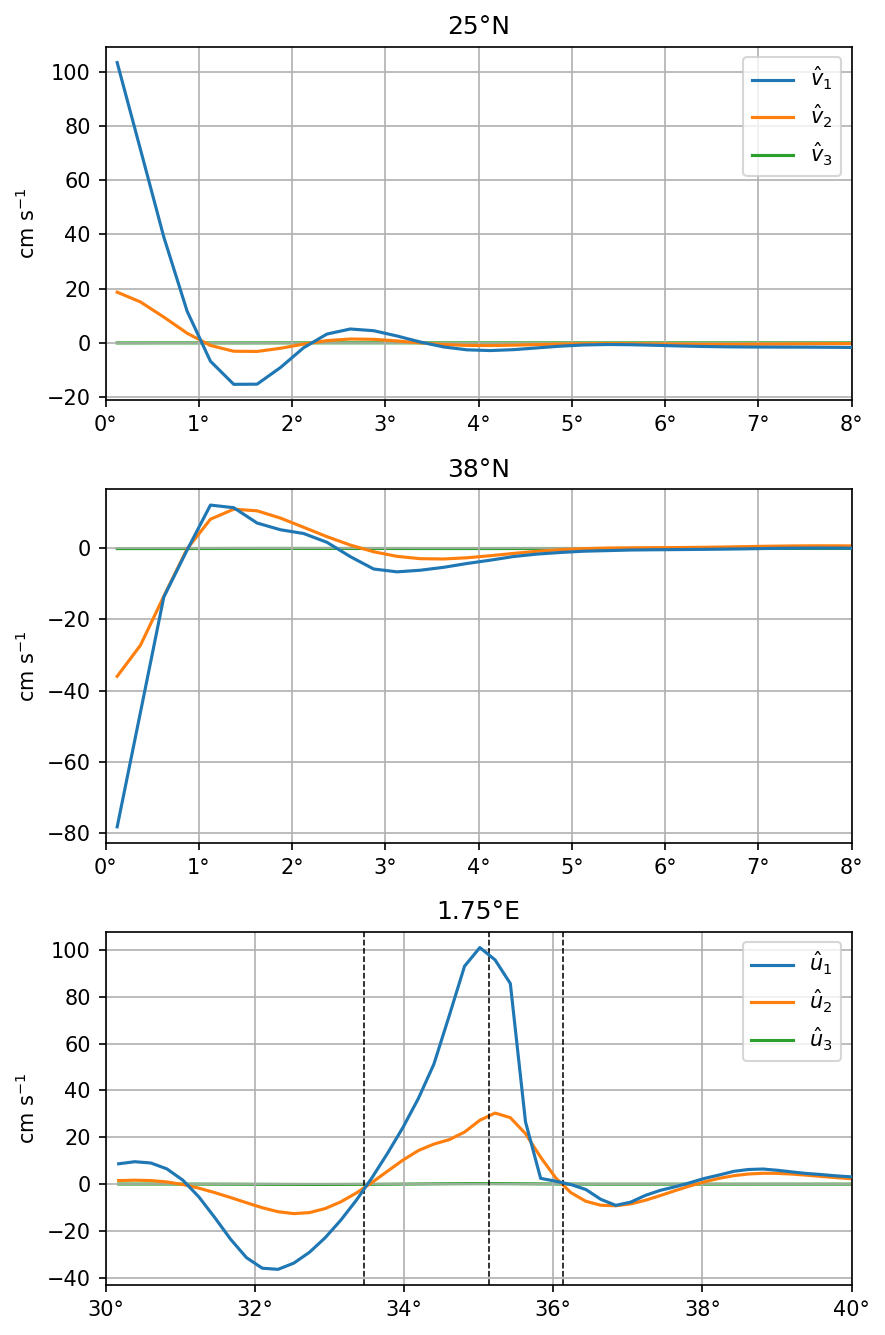

In [430]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = 100*twa.vhat.sel(yq=lat, method='nearest').sel(xh=slice(0, 9))
    for zl in range(Nl):
        ax.plot(fld.xh, fld.isel(zl=zl), label='$\hat{v}_' + str(zl+1) + '$', zorder=3-zl)
    # ax.plot(fld.xh, fld.isel(zl=0), label='$\hat{v}_1$', zorder=3)
    # ax.plot(fld.xh, fld.isel(zl=1), label='$\hat{v}_2$')
    ax.grid()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
axs[0].legend()

ax = axs[2]
lon = recirc_lon0
fld = 100*twa.uhat.sel(xq=lon, method='nearest').sel(yh=slice(30, 41))
for zl in range(Nl):
    ax.plot(fld.yh, fld.isel(zl=zl), label='$\hat{u}_' + str(zl+1) + '$', zorder=3-zl)
ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
ax.grid()
ax.legend()
ax.set_title('{:.2f}\N{DEGREE SIGN}E'.format(recirc_lon0))
ax.set_xlim([30, 40])
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))

for ax in axs:
    ax.set_ylabel('cm s$^{-1}$')

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_velocities')

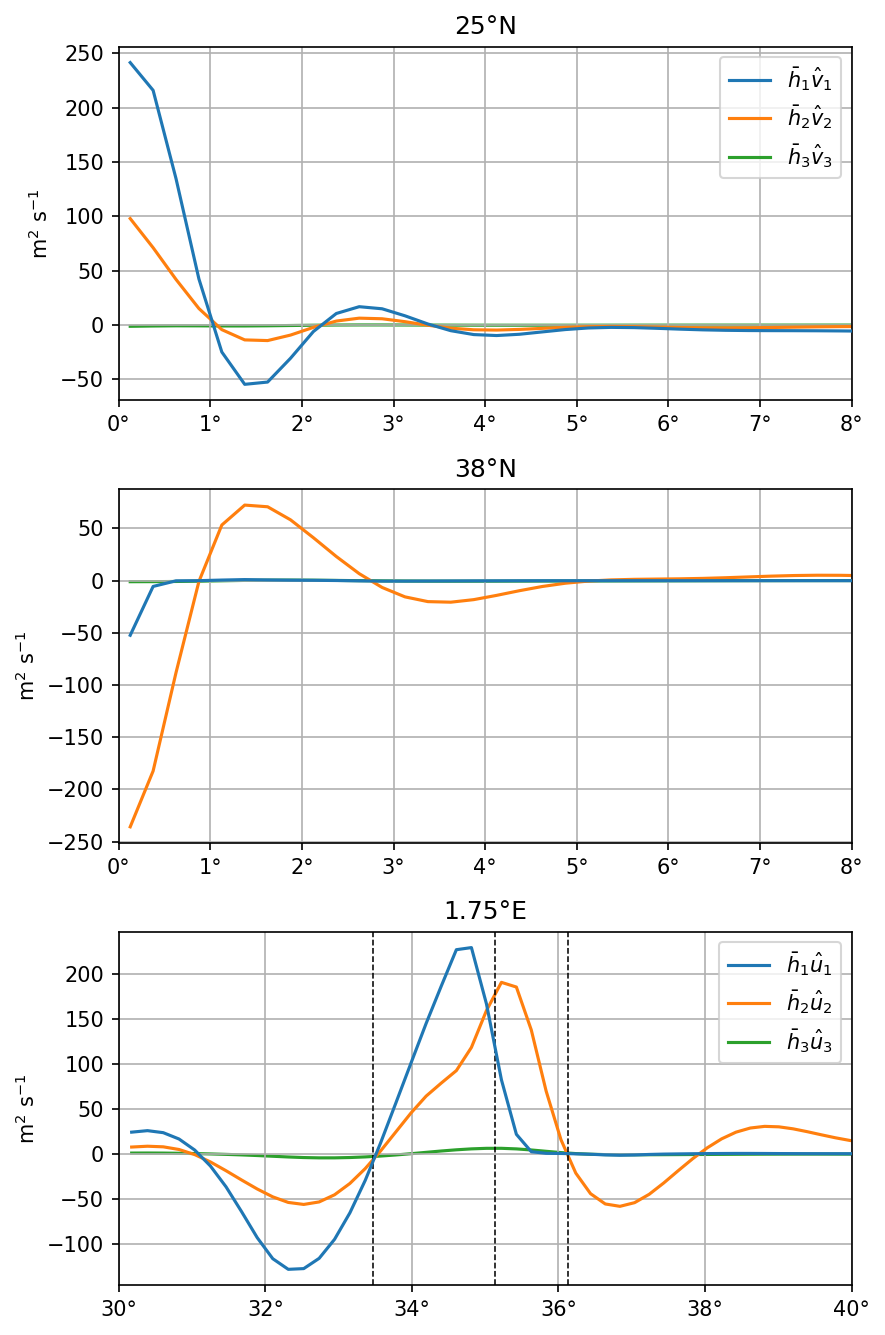

In [431]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = (twa.h_at_v*twa.vhat).sel(yq=lat, method='nearest').sel(xh=slice(0, 9))
    for zl in range(Nl):
        ax.plot(fld.xh, fld.isel(zl=zl), label=r'$\bar{h}_' + str(zl+1) + '\hat{v}_' + str(zl+1) + '$', zorder=3-zl)
    ax.grid()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
axs[0].legend()

ax = axs[2]
lon = recirc_lon0
fld = (twa.h_at_u*twa.uhat).sel(xq=lon, method='nearest').sel(yh=slice(30, 41))
for zl in range(Nl):
    ax.plot(fld.yh, fld.isel(zl=zl), label=r'$\bar{h}_' + str(zl+1) + '\hat{u}_' + str(zl+1) + '$', zorder=3-zl)
ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
ax.grid()
ax.legend()
ax.set_title('{:.2f}\N{DEGREE SIGN}E'.format(recirc_lon0))
ax.set_xlim([30, 40])
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


for ax in axs:
    ax.set_ylabel('m$^2$ s$^{-1}$')

fig.subplots_adjust(hspace=.3)
fig.tight_layout()

savefig(fig, 'wbc_transports')

In [432]:
# fig, axs = plt.subplots(nrows=3, figsize=(6,8))

# for n, lat in enumerate([25, 38]):
#     ax = axs[n]
#     fld = 1/twa.Pi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
#     ax.plot(fld.xq, fld.isel(zl=0), color=colors[0])
#     ax.tick_params(axis='y', labelcolor=colors[0])
#     ax.set_ylabel(r'$\Pi^{\sharp_1-1}_1$ [m s]', color=colors[0])
#     ax2 = ax.twinx()
#     ax2.plot(fld.xq, fld.isel(zl=1), color=colors[1])
#     ax2.tick_params(axis='y', labelcolor=colors[1])
#     ax2.set_ylabel(r'$\Pi^{\sharp-1}_2$ [m s]', color=colors[1])
#     ax.set_xlim([0, 8])
#     ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
#     xticks = np.arange(0, 9, 1)
#     lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
#     ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
    

# ax = axs[2]
# lon = recirc_lon0
# fld = 1/twa.Pi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
# ax.plot(fld.yq, fld.isel(zl=0), color=colors[0])
# ax.tick_params(axis='y', labelcolor=colors[0])
# ax.set_ylabel(r'$\Pi^{\sharp_1-1}_1$ [m s]', color=colors[0])
# # ax.set_ylim(0, 1.5e-6)
# ax.axvline(recirc_lat0, color='k', ls='--')
# ax2 = ax.twinx()
# ax2.plot(fld.yq, fld.isel(zl=1), color=colors[1])
# ax2.tick_params(axis='y', labelcolor=colors[1])
# ax2.set_ylabel(r'$\Pi^{\sharp_1-1}_2$ [m s]', color=colors[1])
# ax.set_xlim([30, 40])
# ax.set_title(str(lon) + '\N{DEGREE SIGN}E')

# xticks = np.arange(30, 41, 2)
# latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
# ax.set_xticks(xticks, labels=latFormatter.format(xticks))

# fig.subplots_adjust(hspace=.3)

# # I don't know why, but the figure color gets set to none at some point. This sets it back.
# fig.set_facecolor('w')

# fig.tight_layout()
# savefig(fig, 'wbc_PV')

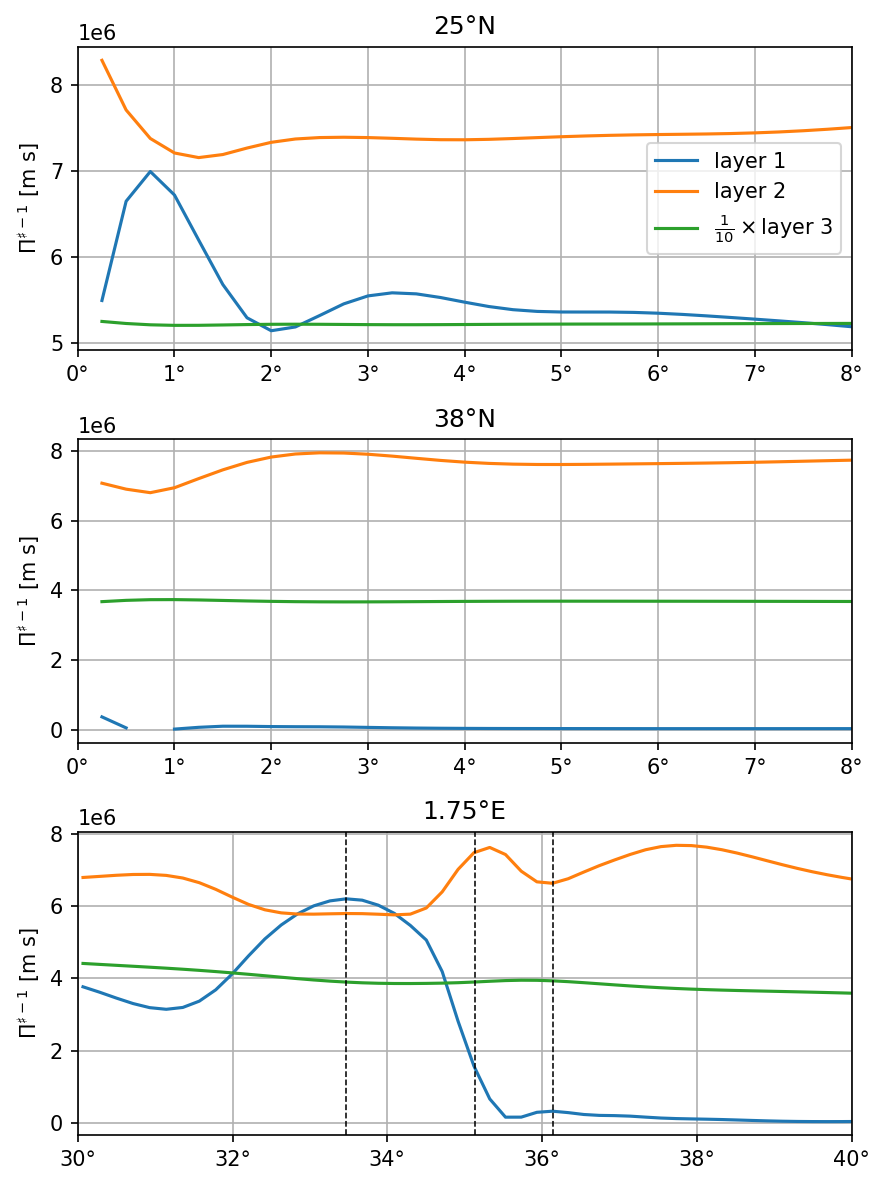

In [433]:
fig, axs = plt.subplots(nrows=3, figsize=(6,8))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = 1/twa.Pi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    # for zl in range(Nl):
        # ax.plot(fld.xq, fld.isel(zl=zl), label='layer ' + str(zl+1), zorder=3-zl)
    ax.plot(fld.xq, fld.isel(zl=0), label='layer 1')
    ax.plot(fld.xq, fld.isel(zl=1), label=r'layer 2')
    ax.plot(fld.xq, fld.isel(zl=2)/10, label=r'$\frac{1}{10}\times$layer 3')
    ax.set_ylabel(r'$\Pi^{\sharp-1}$ [m s]')
    ax.grid()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
    
axs[0].legend()

ax = axs[2]
lon = recirc_lon0
fld = 1/twa.Pi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld.isel(zl=0), label='layer 1')
ax.plot(fld.yq, fld.isel(zl=1), label=r'layer 2')
ax.plot(fld.yq, fld.isel(zl=2)/10, label=r'$\frac{1}{10}\times$layer 3')
# for zl in range(Nl):
#     ax.plot(fld.yq, fld.isel(zl=zl), label='layer ' + str(zl+1), zorder=3-zl)
# ax.plot(fld.yq, fld.isel(zl=0), color=colors[0])
ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
# ax.plot(fld.yq, fld.isel(zl=1)/9, color=colors[1])
ax.set_ylabel(r'$\Pi^{\sharp-1}$ [m s]')
ax.grid()
ax.set_xlim([30, 40])
ax.set_title('{:.2f}\N{DEGREE SIGN}E'.format(recirc_lon0))

xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))

fig.subplots_adjust(hspace=.3)

# I don't know why, but the figure color gets set to none at some point. This sets it back.
fig.set_facecolor('w')

fig.tight_layout()
savefig(fig, 'wbc_PV')

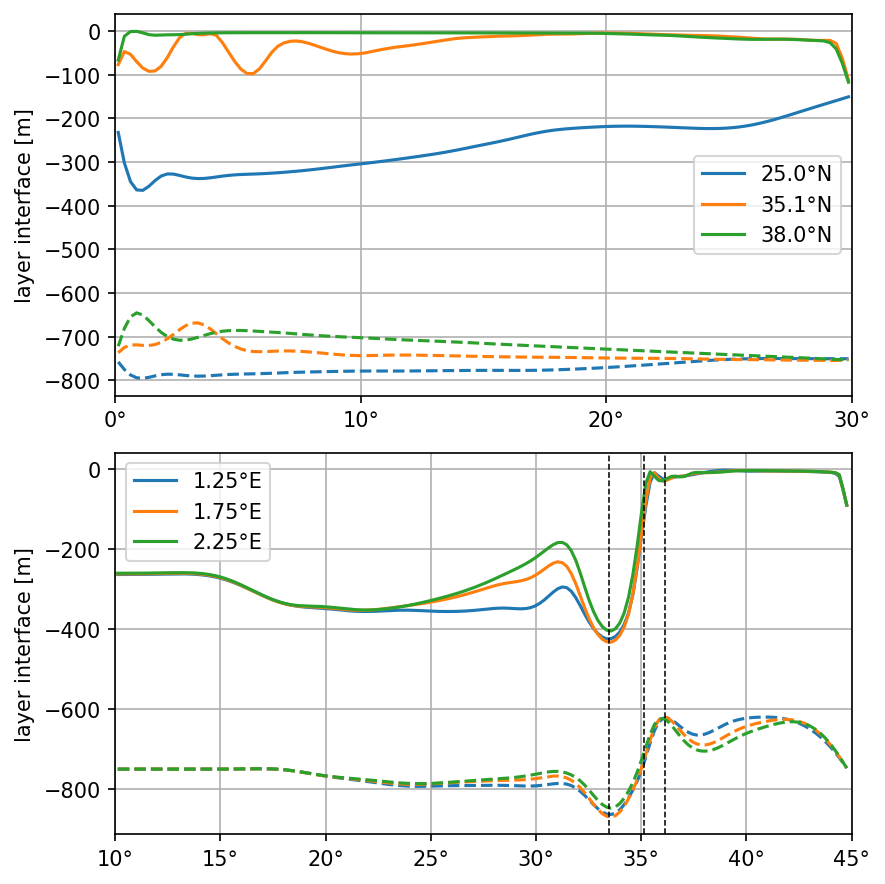

In [434]:
fig, axs = plt.subplots(nrows=2, figsize=(6,6))



ax = axs[0]
for lat in (25, recirc_lat0, 38):
    fld = prog.e.isel(time=tavg).mean(dim='time').sel(yh=lat, method='nearest')
    line, = ax.plot(fld.xh, fld.isel(zi=1), label='{:.1f}\N{DEGREE SIGN}N'.format(lat))
    if Nl > 2:
        ax.plot(fld.xh, fld.isel(zi=2), color=line.get_color(), ls='--')
    # ax.fill_between(fld.xh, -max_depth, fld.isel(zi=-1), color='.7')
    
ax.legend()
ax.set_xlim(0, 30)
ax.grid()

xticks = np.arange(0, 31, 10)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=lonFormatter.format(xticks))    

ax = axs[1]
for lon in (recirc_lon0 - 0.5, recirc_lon0, recirc_lon0 + .5):
    fld = prog.e.isel(time=tavg).mean(dim='time').sel(xh=lon, method='nearest')
    line, = ax.plot(fld.yh, fld.isel(zi=1), label='{:.2f}\N{DEGREE SIGN}E'.format(lon))
    if Nl > 2:
        ax.plot(fld.yh, fld.isel(zi=2), color=line.get_color(), ls='--')        
ax.legend()
ax.set_xlim(10, 45)
ax.grid()
ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
ax.axvline(recirc_latS, color='k', ls='--', lw=.75)

xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


for ax in axs:
    ax.set_ylabel('layer interface [m]')

fig.tight_layout()
savefig(fig, 'layer_interface')

## Recirculation

1.2499999999999998 96.84454054138756
1.7499999999999998 101.2413823035164
2.25 99.72861315992088


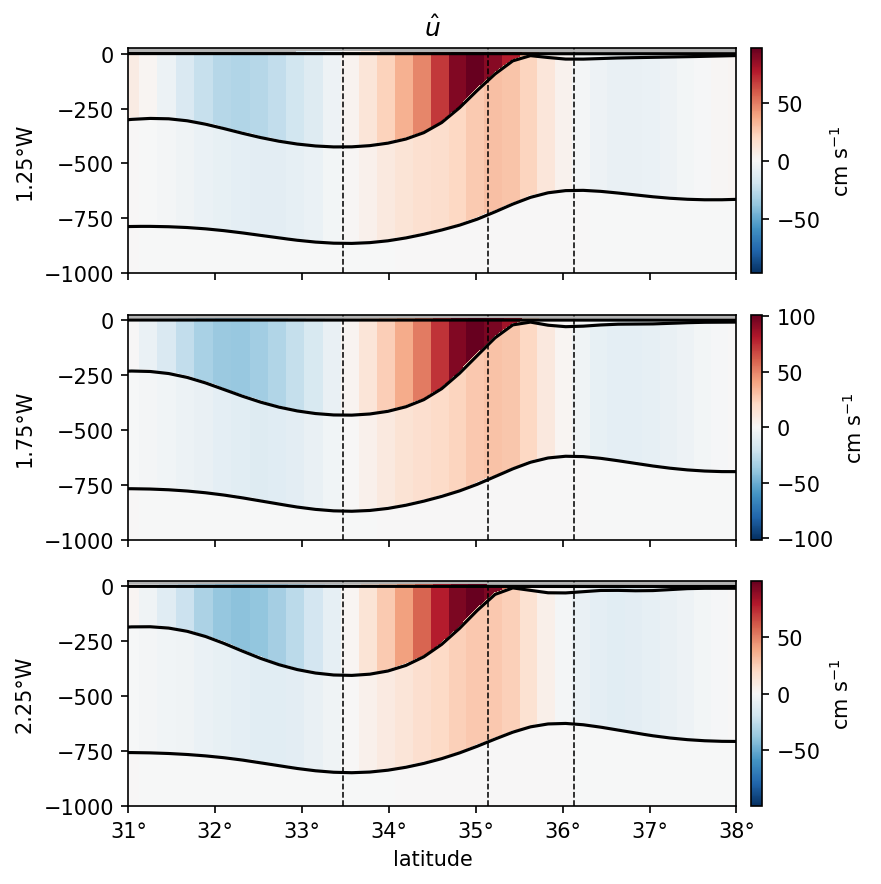

In [435]:
xlocs = [recirc_lon0 - .5, recirc_lon0, recirc_lon0 +.5]

fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6,6))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat, 'X')
for xloc, ax in zip(xlocs, axs):
    ax.set_facecolor('.7')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        u.sel(xh=xloc, method='nearest').values, representation='linear')
    print(xloc, np.abs(q).max())
    vmax = np.nanmax(np.abs(q))
    # vmax = 110
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    ax.plot(y, z.T, color='k')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$', pad=.02)
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
    ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
        
ax.set_ylim([-1000, 25])
ax.set_xlim(recirc_lat)
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{u}$')

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

savefig(fig, 'recirc_meridional_u')

1.2499999999999998 41.04591540464989
1.7499999999999998 39.03672413334432
2.25 44.534824786899044


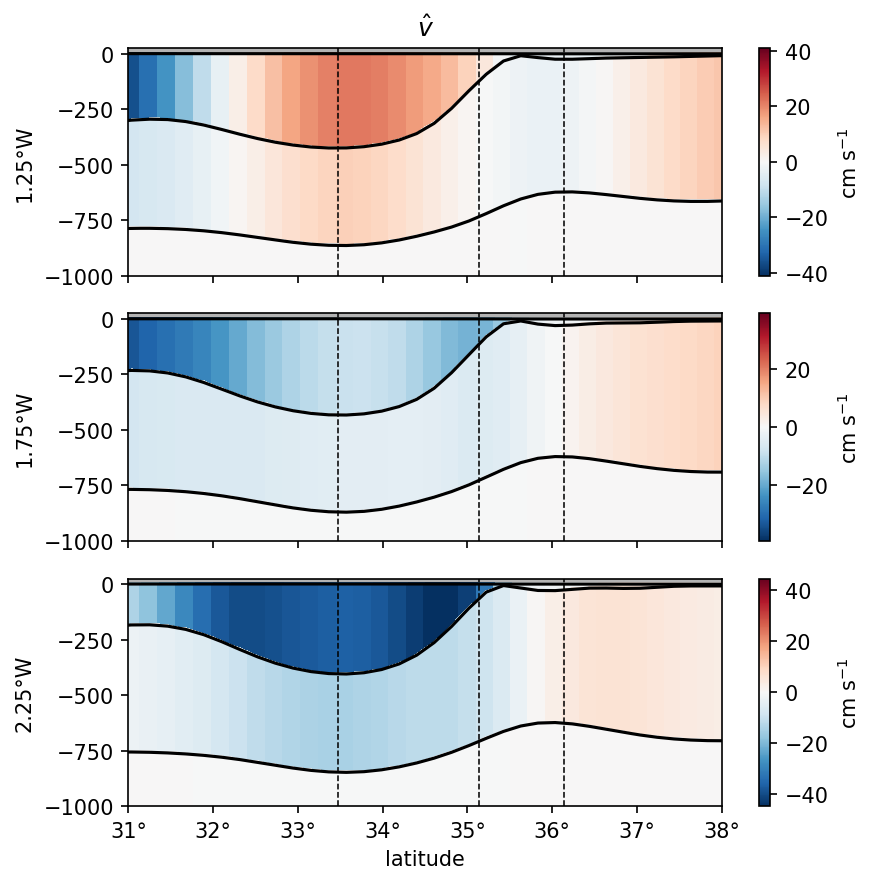

In [436]:
xlocs = [recirc_lon0 - .5, recirc_lon0, recirc_lon0 +.5]

fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6,6))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
for xloc, ax in zip(xlocs, axs):
    ax.set_facecolor('.7')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        v.sel(xh=xloc, method='nearest').values, representation='linear')
    print(xloc, np.nanmax(np.abs(q)))
    # vmax = 50
    vmax = np.nanmax(np.abs(q))
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    ax.plot(y, z.T, color='k')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
    ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
        
ax.set_ylim([-1000, 25])
ax.set_xlim(recirc_lat)
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{v}$')

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

savefig(fig, 'recirc_meridional_v')

36.135814276347745 12.934773228404229
35.13969802856445 97.43463826615397
33.46760897645524 24.241568412578797


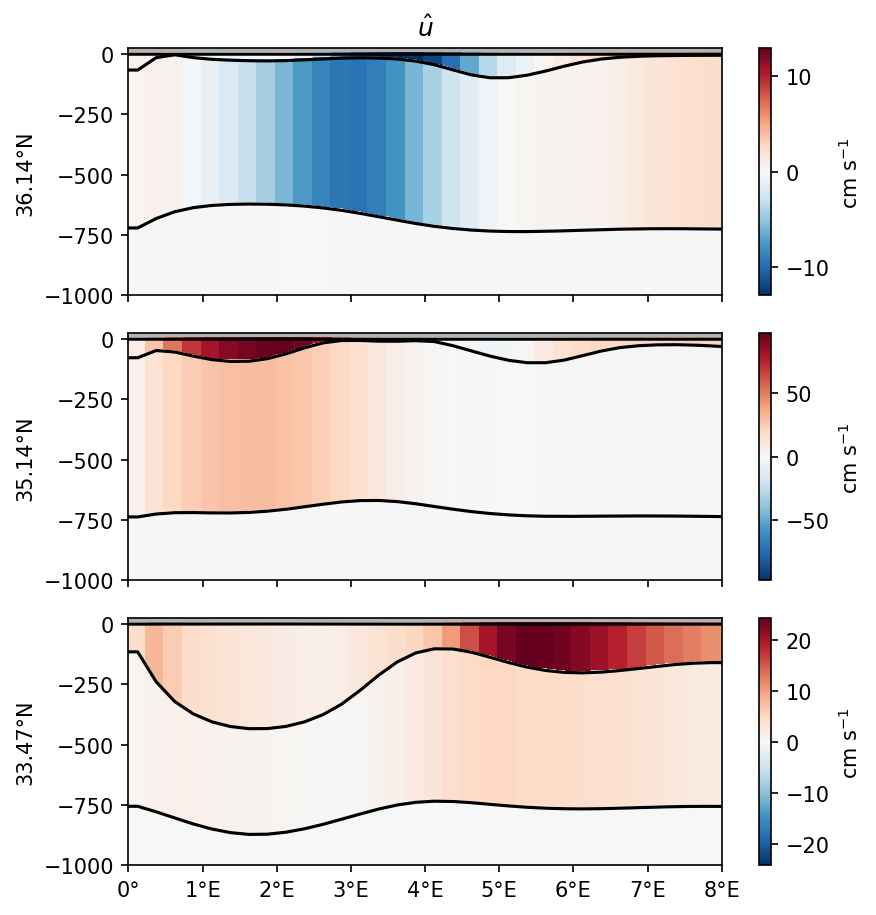

In [437]:
ylocs = [recirc_latN, recirc_lat0, recirc_latS]

fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6,6))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat.fillna(0), 'X')
for yloc, ax in zip(ylocs, axs):
    ax.set_facecolor('.7')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        u.sel(yh=yloc, method='nearest').values, representation='linear')
    # vmax = 110
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, float(np.abs(u.sel(yh=yloc, method='nearest')).max()))
    ax.plot(x, z.T, color='k')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:.2f}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim(recirc_lon)

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=True)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{u}$')

savefig(fig, 'recirc_zonal_u')

36.135814276347745 77.43606825424452
35.13969802856445 46.19160580830304
33.46760897645524 154.88467082115386


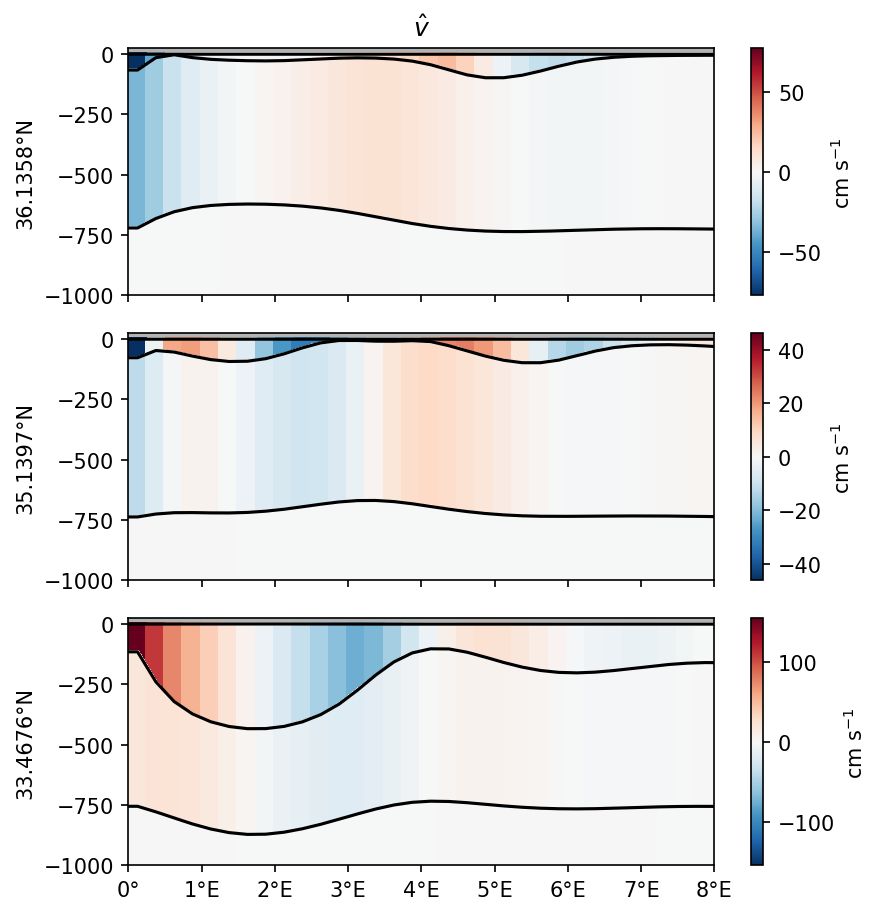

In [438]:
ylocs = [recirc_latN, recirc_lat0, recirc_latS]

fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6,6))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
vms = [55, 70, 85, 75, 45]
for yloc, ax, vmax in zip(ylocs, axs, vms):
    ax.set_facecolor('.7')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        v.sel(yh=yloc, method='nearest').values, representation='linear')
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, np.abs(q).max())
    ax.plot(x, z.T, color='k')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim(recirc_lon)

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=True)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{v}$')

savefig(fig, 'recirc_zonal_v')

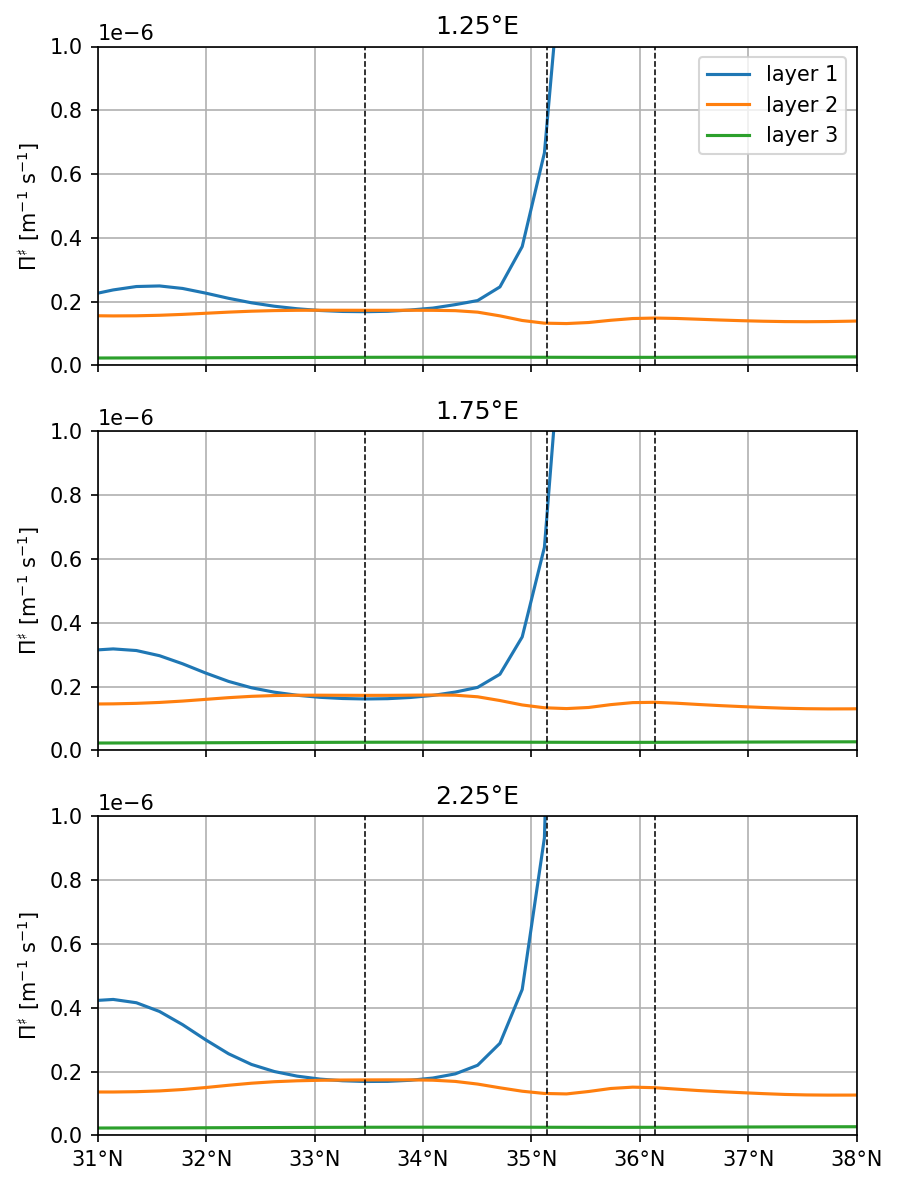

In [439]:
xlocs = [recirc_lon0 - .5, recirc_lon0, recirc_lon0 +.5]

fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(6,8))

for n, lon in enumerate(xlocs):
    ax = axs[n]
    fld = twa.Pi.sel(xq=lon, method='nearest').sel(yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))
    ax.plot(fld.yq, fld.isel(zl=0), label='layer 1')
    ax.plot(fld.yq, fld.isel(zl=1), label=r'layer 2')
    ax.plot(fld.yq, fld.isel(zl=2), label=r'layer 3')
    ax.set_ylabel(r'$\Pi^{\sharp}$ [m$^{-1}$ s$^{-1}$]')
    ax.grid()
    ax.set_xlim(recirc_lat)
    ax.set_ylim(0, 1e-6)
    ax.set_title('{:.2f}\N{DEGREE SIGN}E'.format(lon))
    ax.axvline(recirc_lat0, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latN, color='k', ls='--', lw=.75)
    ax.axvline(recirc_latS, color='k', ls='--', lw=.75)
    
axs[0].legend()

fig.subplots_adjust(hspace=.3)

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
lonFormatter = pw.plt.LatitudeFormatter(direction_labels=True)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
savefig(fig, 'recirc_meridional_PV')

[Text(0.0, 0, '0°'),
 Text(1.0, 0, '1°E'),
 Text(2.0, 0, '2°E'),
 Text(3.0, 0, '3°E'),
 Text(4.0, 0, '4°E'),
 Text(5.0, 0, '5°E'),
 Text(6.0, 0, '6°E'),
 Text(7.0, 0, '7°E'),
 Text(8.0, 0, '8°E')]

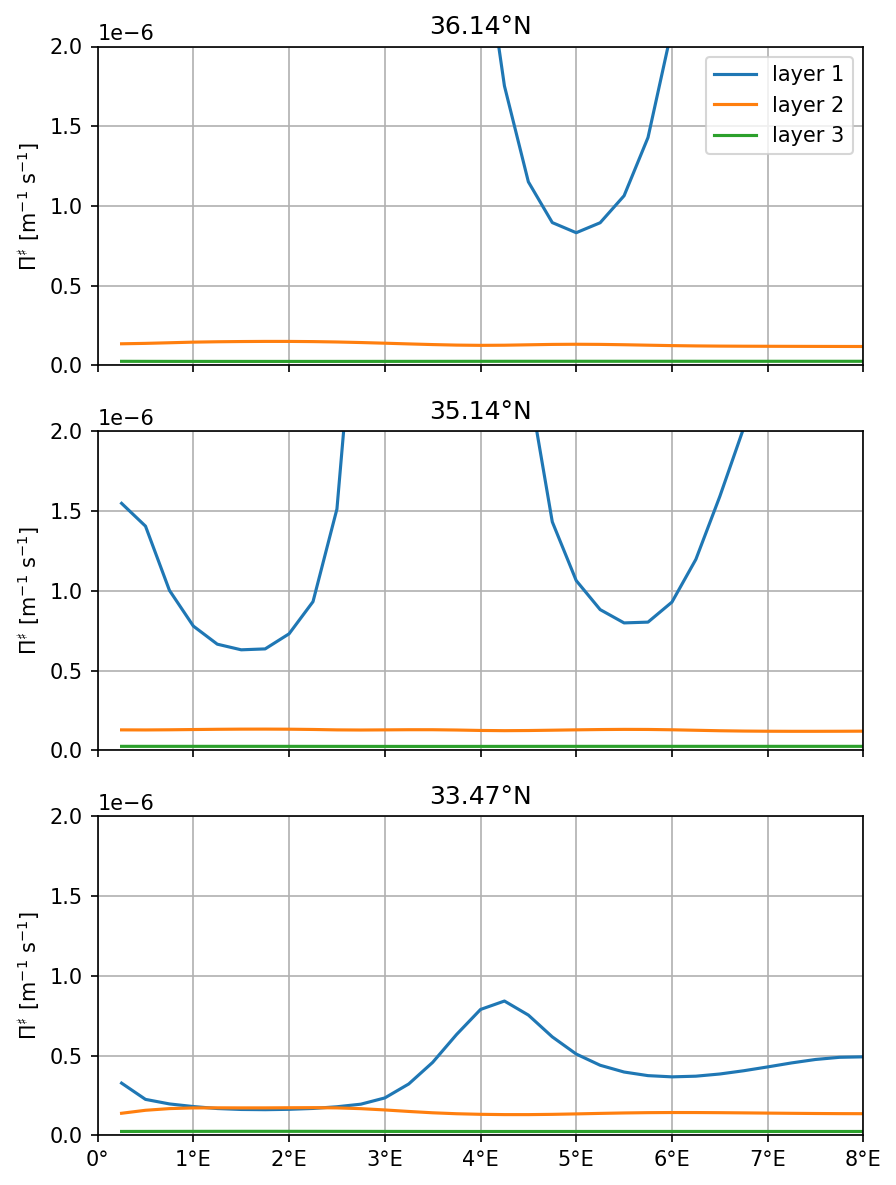

In [440]:
ylocs = [recirc_latN, recirc_lat0, recirc_latS]

fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(6,8))

for n, lat in enumerate(ylocs):
    ax = axs[n]
    fld = twa.Pi.sel(yq=lat, method='nearest').sel(xq=slice(recirc_lon[0]-.5, recirc_lon[1]+.5))
    ax.plot(fld.xq, fld.isel(zl=0), label='layer 1')
    ax.plot(fld.xq, fld.isel(zl=1), label=r'layer 2')
    ax.plot(fld.xq, fld.isel(zl=2), label=r'layer 3')
    ax.set_ylabel(r'$\Pi^{\sharp}$ [m$^{-1}$ s$^{-1}$]')
    ax.grid()
    ax.set_xlim(recirc_lon)
    ax.set_ylim(0, 2e-6)
    ax.set_title('{:.2f}\N{DEGREE SIGN}N'.format(lat))
    
axs[0].legend()

fig.subplots_adjust(hspace=.3)

fig.align_ylabels(axs)
fig.tight_layout()

fig.canvas.draw()
xticks = ax.get_xticks()
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=True)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
# savefig(fig, 'recirc_meridional_PV')

## Streamfunctions

### Barotropic

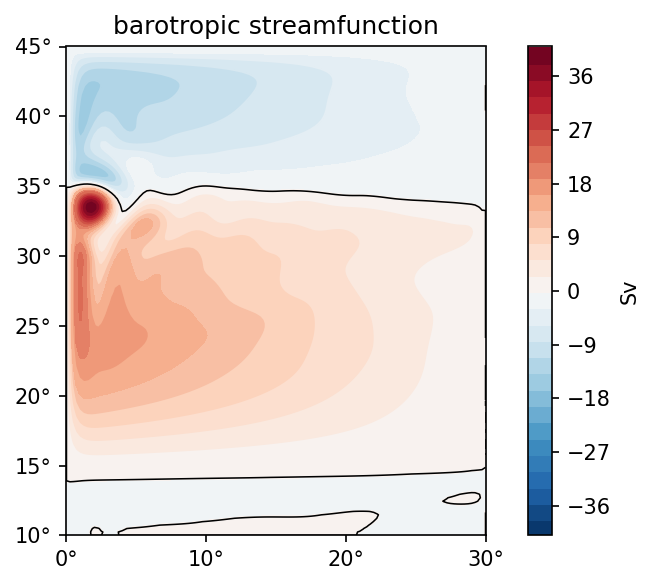

In [441]:
vmax = np.ceil(float(np.abs(psiB).max()))
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

fig, ax = plt.subplots()
setup_plan_plot(ax)
cs = ax.contourf(psiB.xq, psiB.yq, psiB, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.contour(psiB.xq, psiB.yq, psiB, levels=[0], colors='k', linewidths=.75)
# ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
ax.set_aspect(1)
fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=5), label='Sv').solids.set_edgecolor('face')
ax.set_title('barotropic streamfunction')

fig.tight_layout()
savefig(fig, 'barotropic_streamfunction')

### Layerwise

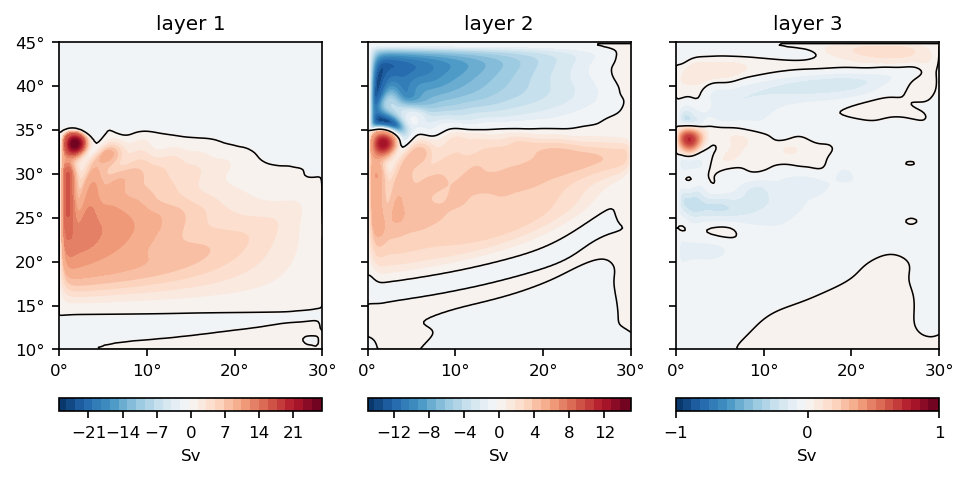

In [442]:
with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))

    for zl, ax in enumerate(axs):
        setup_plan_plot(ax)
        vmax = np.ceil(float(np.abs(psi.isel(zl=zl)).max()))
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.contour(psi.xq, psi.yq, psi.isel(zl=zl), levels=[0], colors='k', linewidths=.75)
        fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=4), orientation='horizontal', 
                     label='Sv', pad=.1).solids.set_edgecolor('face')
        ax.set_title('layer ' + str(zl+1))

    fig.tight_layout()
    savefig(fig, 'layer_streamfunctions')

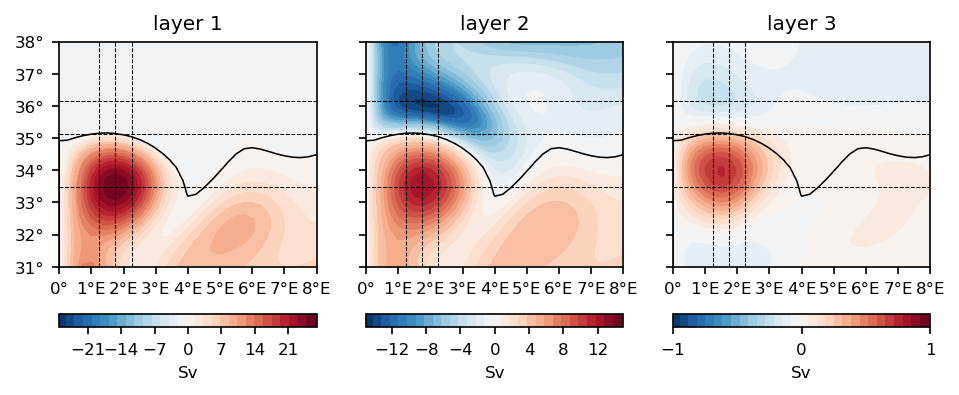

In [443]:
fld = psi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))

    # The contour is the zero of the barotropic streamfunction
    for zl, ax in enumerate(axs):
        setup_plan_plot(ax)
        vmax = np.ceil(float(np.abs(fld.isel(zl=zl)).max()))
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.contour(psi.xq, psi.yq, psi.sum(dim='zl'), levels=[0], colors='k', linewidths=.75)
        fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=4), orientation='horizontal', 
                     label='Sv', pad=.1).solids.set_edgecolor('face')
        ax.set_title('layer ' + str(zl+1))
        for fac in [-.5, 0, .5]:
            ax.axvline(recirc_lon0 + fac, color='k', ls='--', lw=.5)
        ax.axhline(recirc_lat0, color='k', ls='--', lw=.5)
        ax.axhline(recirc_latS, color='k', ls='--', lw=.5)
        ax.axhline(recirc_latN, color='k', ls='--', lw=.5)

    axs[0].set_xlim(recirc_lon)
    axs[0].set_ylim(recirc_lat)
    axs[0].set_aspect(1)
    xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
    yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
    axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
    axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))
    
fig.tight_layout()
savefig(fig, 'layer_streamfunctions_recirc')

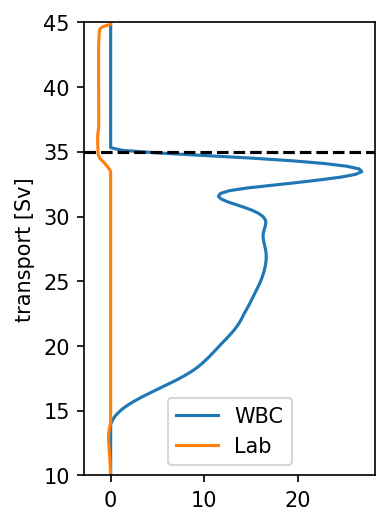

In [444]:
T_wbc = psi.isel(zl=0).sel(xq=slice(0,10)).max(dim='xq')
T_lab = psi.isel(zl=0).sel(xq=slice(0,10)).min(dim='xq')

fig, ax = plt.subplots(figsize=(2.5,4))

ax.plot(T_wbc, T_wbc.yq, label='WBC')
ax.plot(T_lab, T_wbc.yq, label='Lab')
ax.set_ylabel('transport [Sv]')

ax.set_ylim([10, 45])
ax.legend(loc='lower center')
ax.axhline(35, color='k', ls='--')

savefig(fig, 'outcrop_transports_mom')

## Velocities

### Layerwise

In [445]:
# u = 100*grid_op.interp(twa.uhat.fillna(0), 'X')
# v = 100*grid_op.interp(twa.vhat.fillna(0), 'Y')

# speed = np.sqrt(u**2 + v**2)

In [446]:
# fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
# data_projection = ccrs.PlateCarree()

# vm = [100, 4.5]
# cticks = [np.arange(0, 101, 20), np.arange(0, 5, 1)]
# for zl in range(2):
#     ax = axs[zl]
#     setup_cartopy_plot(ax)
#     vmax = vm[zl]
#     vmin = 0
#     levels = np.linspace(vmin, vmax, 64)

#     lw = (5*speed.isel(zl=zl) / vmax).values

#     cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
#                           vmin=vmin, vmax=vmax, cmap='pink_r',
#                           transform=data_projection)
#     for c in cs.collections:
#         c.set_edgecolor('face')
#     sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
#                   transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
#     fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$', pad=.1).solids.set_edgecolor('face')

# axs[0].set_title('layer 1 velocity')
# axs[1].set_title('layer 2 velocity')
    
# fig.tight_layout()
# # I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
# savefig(fig, 'velocities', pdf=False)

In [447]:
# u = 100*grid_op.interp(snapshot.u.isel(time=-1).fillna(0), 'X')
# v = 100*grid_op.interp(snapshot.v.isel(time=-1).fillna(0), 'Y')

# speed = np.sqrt(u**2 + v**2)

In [448]:
# speed.isel(zl=1).max().values

In [449]:
# fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
# data_projection = ccrs.PlateCarree()

# vm = [100, 10]
# cticks = [np.arange(0, vm[0]+1, 20), np.arange(0, vm[1]+1, 1)]
# for zl in range(2):
#     ax = axs[zl]
#     setup_cartopy_plot(ax)
#     vmax = vm[zl]
#     vmin = 0
#     levels = np.linspace(vmin, vmax, 64)

#     lw = (5*speed.isel(zl=zl) / vmax).values

#     cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
#                           vmin=vmin, vmax=vmax, cmap='pink_r',
#                           transform=data_projection)
#     for c in cs.collections:
#         c.set_edgecolor('face')
#     sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
#                   transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
#     fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$', pad=.1).solids.set_edgecolor('face')

# axs[0].set_title('layer 1 velocity')
# axs[1].set_title('layer 2 velocity')
    
# fig.tight_layout()
# # I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
# savefig(fig, 'snapshot_velocities', pdf=False)

### Barotropic

In [450]:
# U = 100*grid_op.interp(cont.uh.isel(time=tavg).mean(dim='time').sum(dim='zl').fillna(0)/grid.dyCu, 'X')/grid.D
# V = 100*grid_op.interp(cont.vh.isel(time=tavg).mean(dim='time').sum(dim='zl').fillna(0)/grid.dxCv, 'Y')/grid.D

# speed = np.sqrt(U**2 + V**2)

In [451]:
# speed.max().values

In [452]:
# fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# data_projection = ccrs.PlateCarree()

# setup_cartopy_plot(ax)
# vmax = float(speed.max())
# vmin = 0
# levels = np.linspace(vmin, vmax, 64)

# lw = (5*speed / vmax).values

# cs = ax.contourf(grid.xh.values, grid.yh.values, speed.values, levels, 
#                       vmin=vmin, vmax=vmax, cmap='pink_r',
#                       transform=data_projection)
# for c in cs.collections:
#     c.set_edgecolor('face')
# sp = ax.streamplot(grid.xh.values, grid.yh.values, U.values, V.values,
#               transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
# fig.colorbar(cs, ax=ax, ticks=np.arange(0, vmax+1, 5), label=r'cm s$^{-1}$').solids.set_edgecolor('face')
# ax.set_title('barotropic velocity')

# # I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
# savefig(fig, 'barotropic_velocities', pdf=False)

## Vorticity

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


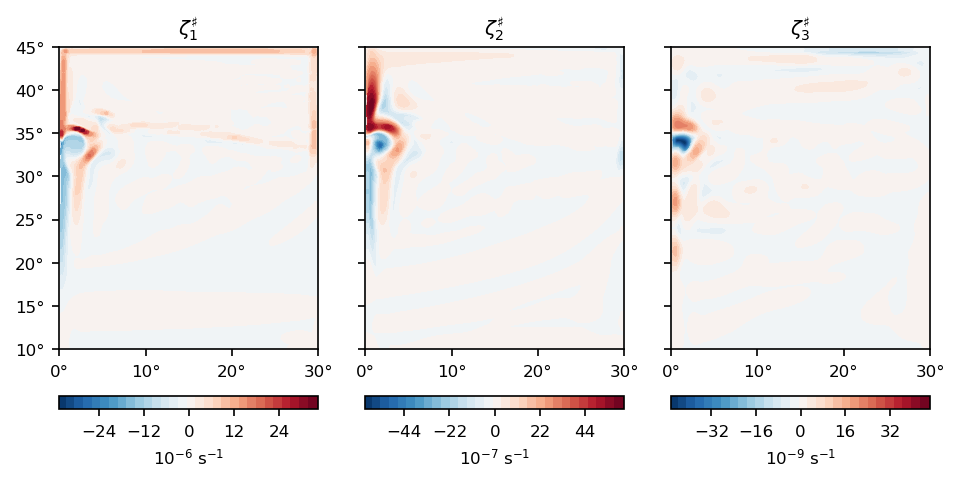

In [453]:
with mpl.style.context({'font.size': 8}):
    if Nl == 2:
        fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

        ax = axs[0]
        setup_plan_plot(ax)
        fld = 1e5*twa.zeta.isel(zl=0)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_1^\sharp$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=1), 
                     pad=.1, label=r'$10^{-5}$ s$^{-1}$').solids.set_edgecolor('face')

        ax = axs[1]
        setup_plan_plot(ax)
        fld = 1e7*twa.zeta.isel(zl=1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_2^\sharp$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=2), 
                     pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')

    elif Nl == 3:
        fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))
        
        ax = axs[0]
        setup_plan_plot(ax)
        fld = 1e6*twa.zeta.isel(zl=0)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_1^\sharp$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-6}$ s$^{-1}$').solids.set_edgecolor('face')

        ax = axs[1]
        setup_plan_plot(ax)
        fld = 1e7*twa.zeta.isel(zl=1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_2^\sharp$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')
        
        ax = axs[2]
        setup_plan_plot(ax)
        fld = 1e9*twa.zeta.isel(zl=2)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_3^\sharp$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-9}$ s$^{-1}$').solids.set_edgecolor('face')
fig.tight_layout()
savefig(fig, 'twa_vorticity')

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


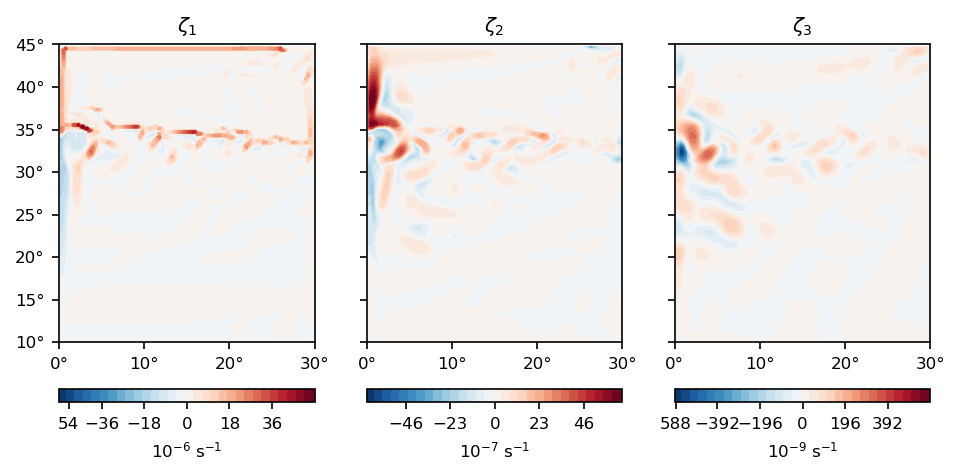

In [454]:
with mpl.style.context({'font.size': 8}):
    if Nl == 2:
        fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

        ax = axs[0]
        setup_plan_plot(ax)
        fld = 1e5*snapshot.zeta.isel(zl=0, time=-1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_1$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=1), 
                     pad=.1, label=r'$10^{-5}$ s$^{-1}$').solids.set_edgecolor('face')

        ax = axs[1]
        setup_plan_plot(ax)
        fld = 1e7*snapshot.zeta.isel(zl=1, time=-1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_2$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=4), 
                     pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')

    elif Nl == 3:
        fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))
        
        ax = axs[0]
        setup_plan_plot(ax)
        fld = 1e6*snapshot.zeta.isel(zl=0, time=-1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_1$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-6}$ s$^{-1}$').solids.set_edgecolor('face')

        ax = axs[1]
        setup_plan_plot(ax)
        fld = 1e7*snapshot.zeta.isel(zl=1, time=-1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_2$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')
        
        ax = axs[2]
        setup_plan_plot(ax)
        fld = 1e9*snapshot.zeta.isel(zl=2, time=-1)
        vmax =  float(np.abs(fld).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        # This is the fix for the white lines between contour levels
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.set_aspect(1)
        ax.set_title(r'$\zeta_3$')
        fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=3), 
                     pad=.1, label=r'$10^{-9}$ s$^{-1}$').solids.set_edgecolor('face')
fig.tight_layout()
savefig(fig, 'snapshot_vorticity')

## PV

This is actually the inverse of the PV. Since the thickness goes to zero, the PV gets very large but it's always bounded away from zero so for sanity we plot the inverse.

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


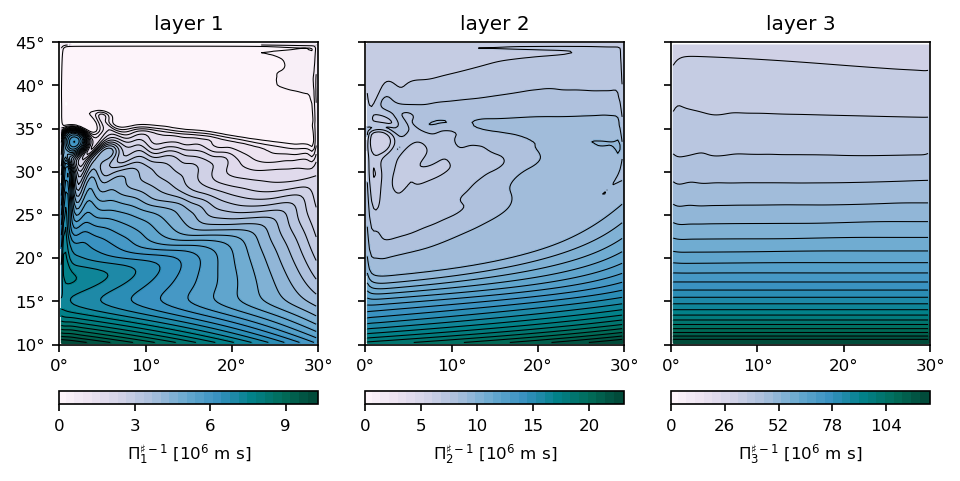

In [455]:
with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))
    
    fld = 1e-6*(1/twa.Pi)
    vmin = 0

    for zl, ax in enumerate(axs):
        setup_plan_plot(ax)
        vmax = float(fld.isel(zl=zl).max())
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn')
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.contour(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, colors='k', linewidths=.5)
        cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$\Pi^{\sharp-1}_' + str(zl+1) + '$ [$10^{6}$ m s]', 
                            ticks=integer_ticks(vmax, symmetric=False, nticks=5))
        cbar.solids.set_edgecolor('face')
        ax.set_title('layer ' + str(zl+1))

fig.tight_layout()
savefig(fig, 'layer_PV')

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


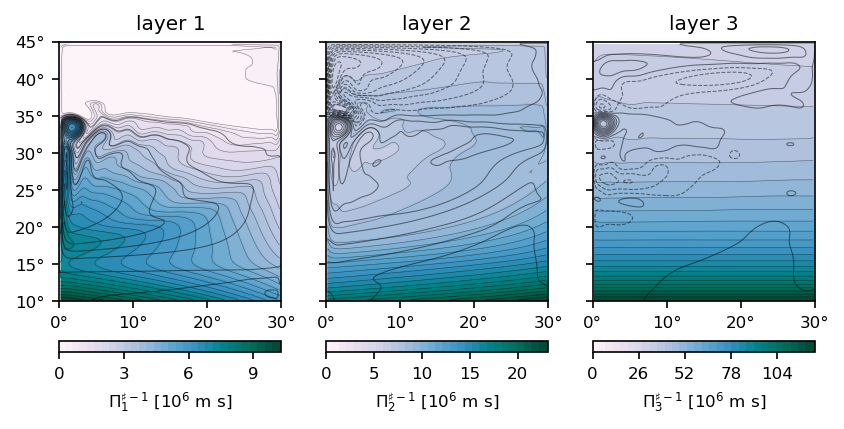

In [456]:
with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))
    
    fld = 1e-6*(1/twa.Pi)
    vmin = 0

    for zl, ax in enumerate(axs):
        setup_plan_plot(ax)
        vmax = float(fld.isel(zl=zl).max())
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn')
        for c in cs.collections:
            c.set_edgecolor('face')
        ax.contour(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, colors='k', linewidths=.25, alpha=.5)
        cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$\Pi^{\sharp-1}_' + str(zl+1) + '$ [$10^{6}$ m s]', 
                            ticks=integer_ticks(vmax, symmetric=False, nticks=5))
        cbar.solids.set_edgecolor('face')
        
        vmax = float(np.abs(psi.isel(zl=zl)).max())
        levels = np.linspace(-vmax, vmax, 21)
        ax.contour(psi.xq, psi.yq, psi.isel(zl=zl), levels=levels, colors='k', linewidths=.5, alpha=.5)

        ax.set_title('layer ' + str(zl+1))

# fig.tight_layout()
savefig(fig, 'layer_steamfunction_PV')

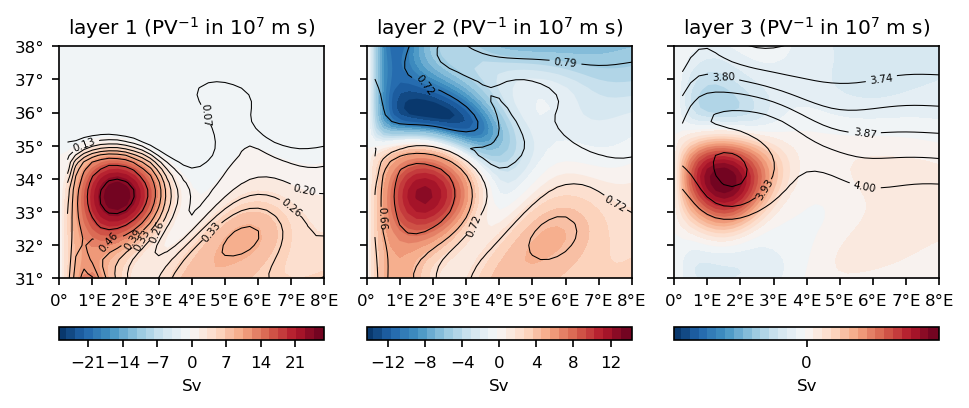

In [457]:
with mpl.style.context({'font.size': 8}):
    fig, axs = plt.subplots(ncols=Nl, sharex=True, sharey=True, figsize=(6.5, 3.5))

    fld = psi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))
    pv = 1e7*twa.Pi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

    for zl, ax in enumerate(axs):
        setup_plan_plot(ax)
        vmax = float(np.abs(fld.isel(zl=zl)).max())
        vmin = -vmax
        levels = np.linspace(vmin, vmax, 31)
        cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
        for c in cs.collections:
            c.set_edgecolor('face')
        cs2 = ax.contour(pv.xq, pv.yq, 1/pv.isel(zl=zl), levels=np.linspace(0, 4, 62), colors='k', linewidths=.5)
        ax.clabel(cs2, fontsize=5, inline_spacing=-8, fmt='%.2f')
        # ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
        fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1, 
                     ticks=integer_ticks(vmax, 4)).solids.set_edgecolor('face')
        ax.set_title('layer ' + str(zl+1) + ' (PV$^{-1}$ in $10^{7}$ m s)')

    # ax = axs[1]
    # setup_plan_plot(ax)
    # vmax = float(np.abs(fld.isel(zl=1)).max())
    # vmin = -vmax
    # levels = np.linspace(vmin, vmax, 31)
    # cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    # for c in cs.collections:
    #     c.set_edgecolor('face')
    # cs2 = ax.contour(pv.xq, pv.yq, 1/(pv.isel(zl=1)), levels=np.linspace(0, 6, 31), colors='k', linewidths=.5)
    # ax.clabel(cs2, fontsize=5, inline_spacing=-7, fmt='%.1f')
    # # ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
    # fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1, ticks=integer_ticks(vmax, 4)).solids.set_edgecolor('face')
    # ax.set_title('layer 2 (PV$^{-1}$ in $10^{7}$ m s)')

    axs[0].set_xlim(recirc_lon)
    axs[0].set_ylim(recirc_lat)
    axs[0].set_aspect(1)
    xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
    yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
    axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
    axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))

    fig.tight_layout()
    savefig(fig, 'layer_streamfunctions_recirc_pv')

In [458]:
# fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# fld = 1e7*twa.Pi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

# ax = axs[0]
# setup_plan_plot(ax)
# vmax = 5
# vmin = 1
# levels = np.linspace(vmin, vmax, 31)
# cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
# for c in cs.collections:
#     c.set_edgecolor('face')
# # ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
# cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(1, 6, 1))
# cbar.solids.set_edgecolor('face')
# ax.set_title('layer 1')

# ax = axs[1]
# setup_plan_plot(ax)
# vmax = .26
# vmin = .21
# levels = np.linspace(vmin, vmax, 31)
# cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
# for c in cs.collections:
#     c.set_edgecolor('face')
# # ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
# cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(.21, .26, .01))
# cbar.solids.set_edgecolor('face')
# ax.set_title('layer 2')

# axs[0].set_xlim(recirc_lon)
# axs[0].set_ylim(recirc_lat)
# axs[0].set_aspect(1)
# xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
# yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
# axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
# axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))

# fig.tight_layout()
# savefig(fig, 'PV_recirc')

## Meridional Sections

1.25 96.84454054138756
5 44.82280529291467
15 45.38443329713737
25 38.50418748964669
28.75 31.649317558013486


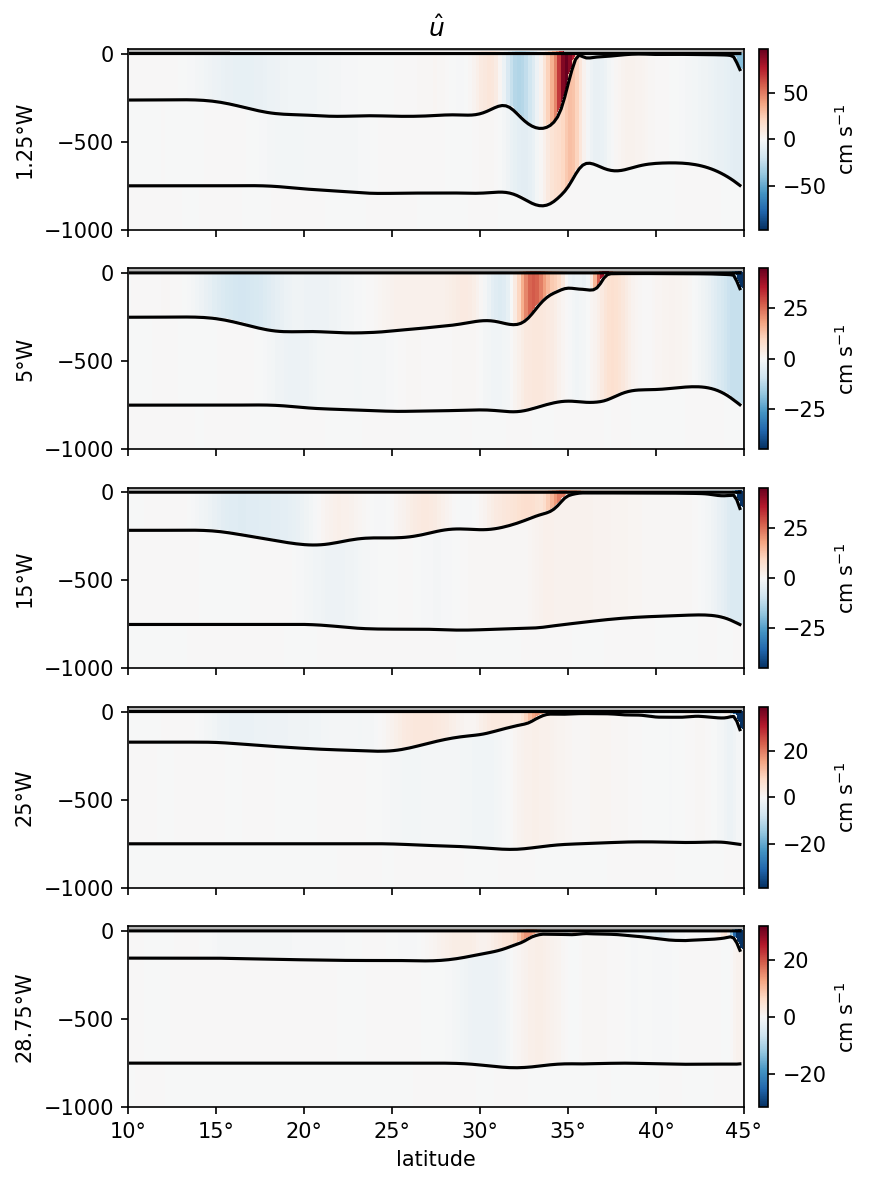

In [459]:
xlocs = [1.25, 5, 15, 25, 28.75]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat, 'X')
for xloc, ax in zip(xlocs, axs):
    ax.set_facecolor('.7')
    for zi in range(Nl):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        u.sel(xh=xloc, method='nearest').values, representation='plm')
    print(xloc, float(np.abs(u.sel(xh=xloc, method='nearest')).max()))
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$', pad=.02)
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{u}$')
xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

fig.tight_layout()
savefig(fig, 'meridional_u')

0.25 116.11525934342588
5 23.69549777764341
15 3.425103211841754
25 4.488825153691721
29.75 44.265275246570425


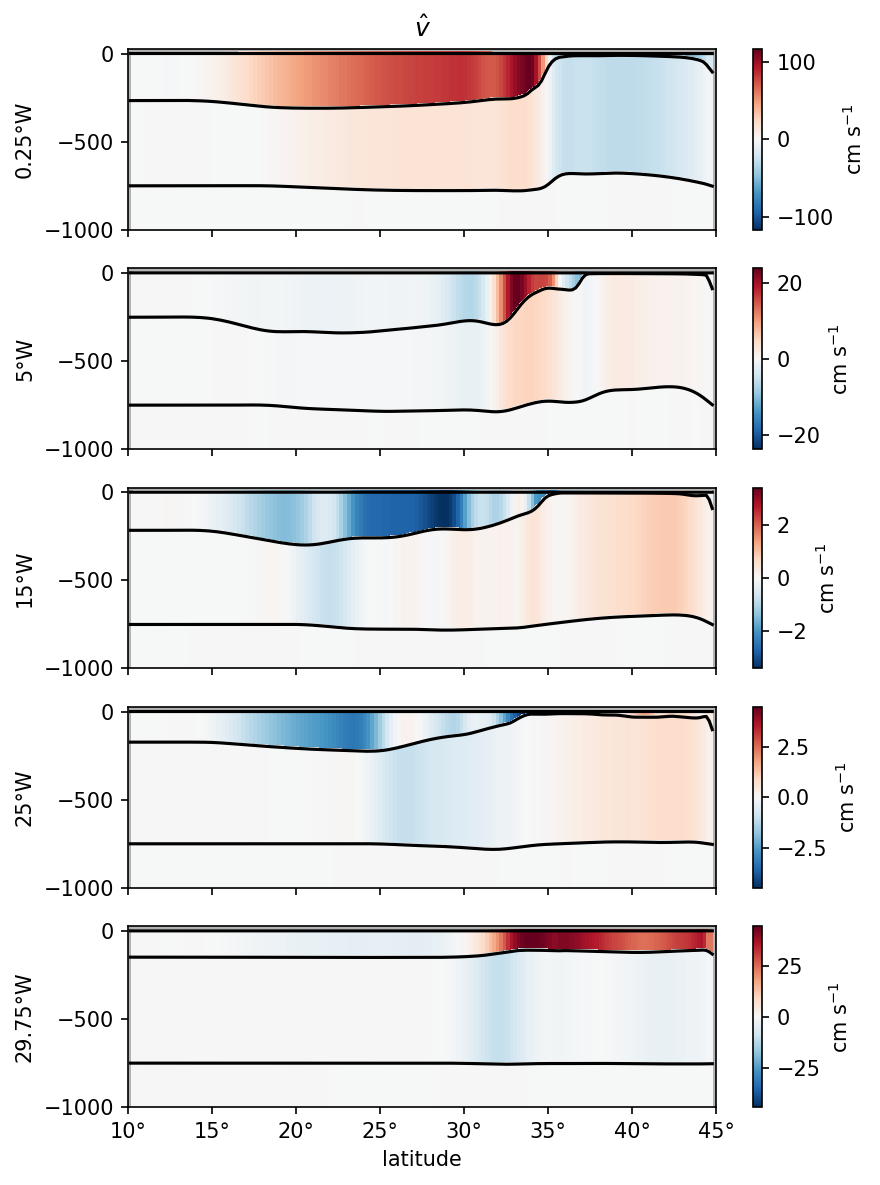

In [460]:
xlocs = [0.25, 5, 15, 25, 29.75]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
for xloc, ax in zip(xlocs, axs):
    ax.set_facecolor('.7')
    for zi in range(Nl):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        v.sel(xh=xloc, method='nearest').values, representation='plm')
    print(xloc, np.nanmax(np.abs(q)))
    vmax = np.nanmax(np.abs(q))
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{v}$')
xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

fig.tight_layout()
savefig(fig, 'meridional_v')

## Zonal Sections

38 8.161074050772708
34.5 61.10560472923885
30 9.304454767768423
25 3.966885219681837
20 3.6737919222896918


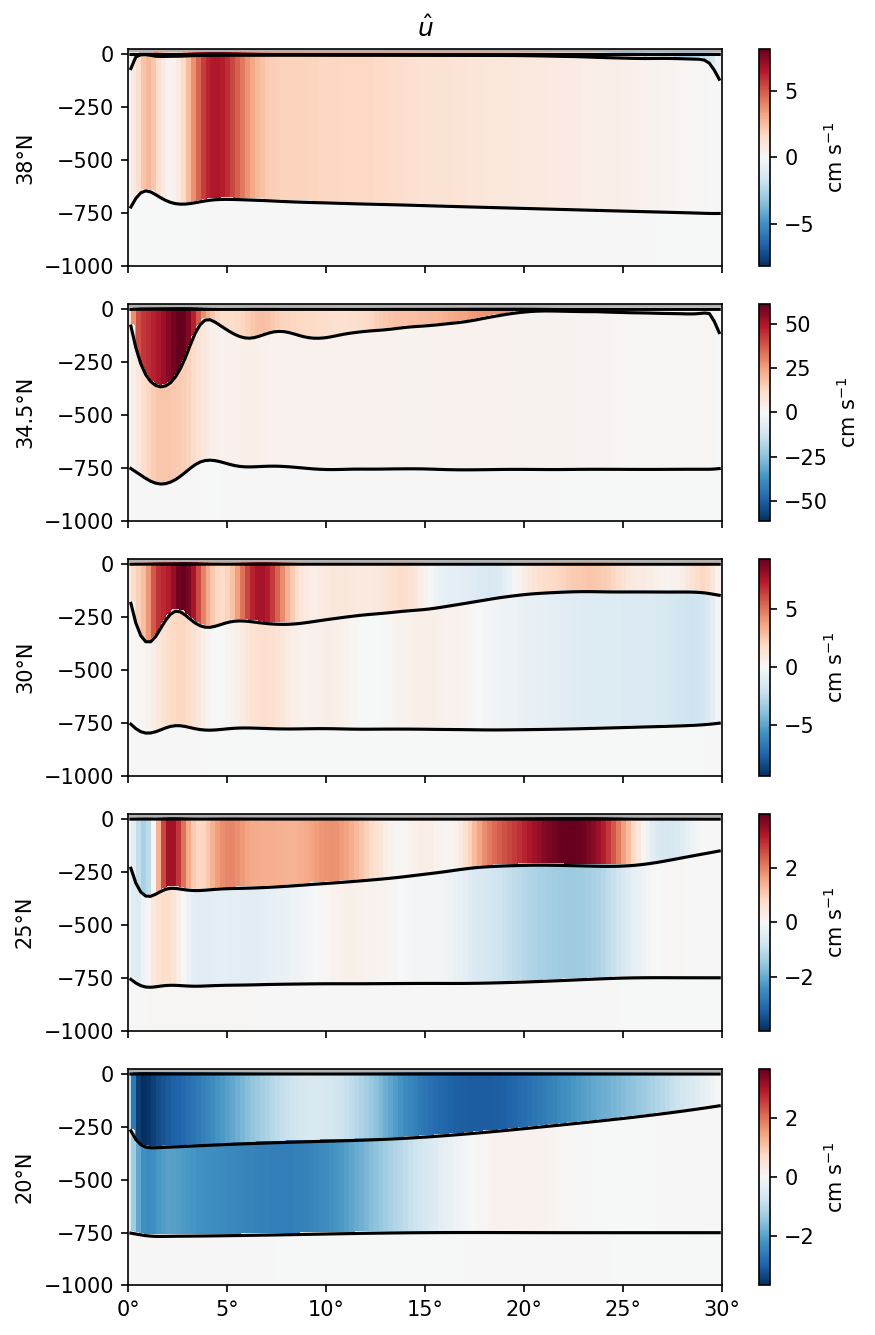

In [461]:
ylocs = [38, 34.5, 30, 25, 20]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,9))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat.fillna(0), 'X')
vms = [20, 15, 4, 2, 4]
for yloc, ax in zip(ylocs, axs):
    ax.set_facecolor('.7')
    for zi in range(Nl):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        u.sel(yh=yloc, method='nearest').values, representation='plm')
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, float(np.abs(u.sel(yh=yloc, method='nearest')).max()))
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])
xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{u}$')

fig.tight_layout()
savefig(fig, 'zonal_u')

38 78.65025083394472
34.5 96.85435827050688
30 120.97815736281234
25 104.06828442150606
20 63.18406922863746


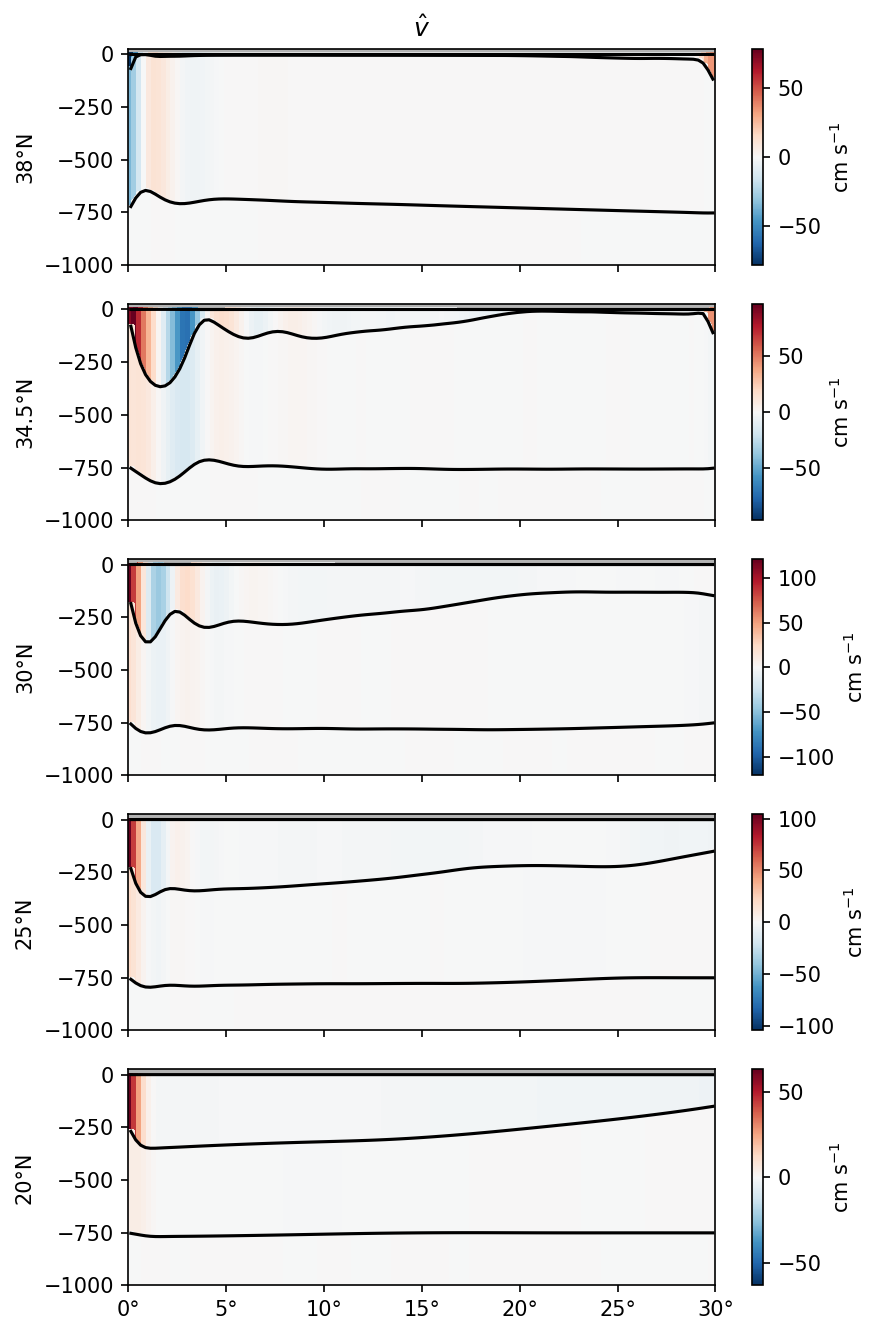

In [462]:
ylocs = [38, 34.5, 30, 25, 20]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,9))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
vms = [55, 70, 85, 75, 45]
for yloc, ax, vmax in zip(ylocs, axs, vms):
    ax.set_facecolor('.7')
    for zi in range(Nl):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        v.sel(yh=yloc, method='nearest').values, representation='plm')
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, float(np.abs(v.sel(yh=yloc, method='nearest')).max()))
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])
xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{v}$')

fig.tight_layout()
savefig(fig, 'zonal_v')

# Close everything

In [463]:
grid.close()
ic.close()
forcing.close()
stats.close()
prog.close()
cont.close()

In [464]:
360*300

108000